<div align="center">

# Notebook 5 AST FINE TUNED

# Classification multi-class FOCH

**Branche Dual pour la classification**

![Python](https://img.shields.io/badge/Python-3.10+-blue?style=flat-square&logo=python)
![PyTorch](https://img.shields.io/badge/PyTorch-2.0+-EE4C2C?style=flat-square&logo=pytorch)
![HuggingFace](https://img.shields.io/badge/🤗-Transformers-FFD21F?style=flat-square)
![CUDA](https://img.shields.io/badge/CUDA-AMP%20Enabled-76B900?style=flat-square&logo=nvidia)

</div>


## Synthèse de l'architecture configurable (upgrade notebook 5)

Cet upgrade rend l'architecture **entièrement pilotable par configuration**, pour comparer plusieurs backbones audio-domaine *sans réécrire la boucle d'entraînement*. Cible : battre la baseline du notebook 5 (**CNN14, 75.2 %, K=5 CV**).

**1 — Backbone configurable (`BACKBONE`, Cellule 1).** Un preset unique sélectionne la/les branche(s) ; la tête de fusion s'adapte automatiquement à la dimension d'embedding, et `forward(input_values, spec)` reste inchangé.

| Preset | Branche audio-domaine (AudioSet) | Branche WavLM | Fusion |
|---|---|---|---|
| `cnn14` *(défaut)* | CNN14 entraînable (2048-d) | WavLM-Base gelé (768-d) | 2816-d |
| `ast` | AST gelé (768-d) | WavLM-Base gelé (768-d) | 1536-d |
| `cnn14_solo` / `ast_solo` | CNN14 / AST seul | — | 2048 / 768-d |
| `wavlm_base` / `wavlm_large` | — | WavLM Base / Large gelé | 768 / 1024-d |

**2 — Gel de WavLM.** Gelé par défaut (`FREEZE_WAVLM=True`, config du meilleur résultat). **Dégel tardif et partiel** optionnel (`UNFREEZE_ENABLED`) : uniquement les `UNFREEZE_LAST_N` dernières couches, à partir de l'époque `UNFREEZE_AT_EPOCH` (≥ 20), à LR discriminant réduit — un petit jeu (~265 enregistrements) ne peut pas remodeler 95–300M paramètres sans dégrader la baseline gelée.

**3 — AST + budget mémoire.** AST chargé **en local** (`ast-finetuned-audioset-10-10-0.4593`), gelé, avec un fbank interne fixe (1024×128) indépendant de la fenêtre. L'arbitrage **fenêtre ↔ batch** est absorbé par l'accumulation de gradient (batch effectif ≈ 16) ; la **sonde VRAM (Cellule 6b)** dimensionne `BATCH_SIZE` — mesuré ≈ 0.27 Go/éch. (`cnn14`+WavLM-Base) → 8 Go : `BATCH_SIZE` 8 ; RTX 5070 Ti 16 Go : 16-24.

> Les explications détaillées accompagnent chaque section (Cellules 1, 6, 6b, 7).

## 1. Configuration de l'environnement et des chemins

Cette première section centralise les dépendances, les chemins **et la sélection du backbone**. Le notebook met en œuvre un **classifieur multi-branche configurable** évalué par **validation croisée stratifiée à 5 plis** (`StratifiedKFold`), avec **augmentation de données injectée pli par pli dans le seul jeu d'entraînement**.

**Classes retenues :**

| Classe | Origine | Justification |
|---|---|---|
| `PR` | FOCH | Pathologie majoritaire (support le plus élevé) |
| `LMB` | FOCH | Support intermédiaire |
| `fuite glottique` | FOCH | Support intermédiaire |
| `Healthy` | Saarbruecken (SVD) | Groupe contrôle — voyelle /a/ à hauteur habituelle |

La classe `Cancer` reste **exclue** (support insuffisant, n ≈ 26). Le déséquilibre des trois pathologies est compensé par des **signaux augmentés** injectés **exclusivement dans le train de chaque pli** ; le pli de validation reste strictement original.

### Sélection configurable du backbone (`BACKBONE`)

Le problème est plus proche de l'**analyse bioacoustique / de signal pathologique** que de la reconnaissance de parole ; on privilégie donc des backbones **audio-domaine pré-entraînés sur AudioSet** plutôt que des modèles centrés parole. Le drapeau `BACKBONE` sélectionne un preset ; le reste du notebook (Dataset, modèle, boucle) s'adapte automatiquement aux dimensions d'embedding.

| Preset | Branche audio-domaine | Branche WavLM | Fusion |
|---|---|---|---|
| `cnn14` *(défaut)* | **CNN14** (PANNs/AudioSet, entraînable, 2048-d) | WavLM-Base gelé (768-d) | 2816-d |
| `ast` | **AST** (AudioSet, ViT spectral, gelé, 768-d) | WavLM-Base gelé (768-d) | 1536-d |
| `cnn14_solo` | CNN14 seul | — | 2048-d |
| `ast_solo` | AST seul | — | 768-d |
| `wavlm_base` | — | WavLM-Base gelé | 768-d |
| `wavlm_large` | — | WavLM-Large gelé (ancienne config nb 6) | 1024-d |

> 💡 **Choix WavLM-Base plutôt que Large** — la branche WavLM apporte le détail acoustique microscopique (jitter, shimmer, apériodicité). On retient la variante **Base** (95M) : dégeler/affiner 300M+ paramètres (Large) n'est pas justifié par la taille du jeu ni le budget de calcul. WavLM restant **gelé** par défaut, Base suffit ; Large reste sélectionnable (`wavlm_large`) au prix d'une VRAM plus élevée.

### Stratégie de gel de WavLM (résumé)

Par défaut `FREEZE_WAVLM=True` (embeddings gelés) — c'est la configuration du meilleur résultat obtenu jusqu'ici (**75.2 %**, WavLM gelé + planificateur LR, sans dégel). Un **dégel tardif partiel** optionnel (`UNFREEZE_ENABLED`) n'affine que les `UNFREEZE_LAST_N` dernières couches transformer, et seulement à partir de l'époque `UNFREEZE_AT_EPOCH`. Détails et justification en Cellule 6.

### Arbitrage fenêtre ↔ taille de batch

La **fenêtre audio** (`MAX_LEN_S`) fixe la résolution temporelle du spectrogramme Mel de CNN14 (`T = MAX_LEN/HOP + 1`). Une fenêtre plus **longue** = plus de trames = **plus de VRAM par échantillon**, ce qui force un **batch physique plus petit** (source d'instabilité de gradient constatée au notebook 6 avec un batch de 2). Deux leviers :

- **Accumulation de gradient** (`ACCUM_STEPS`) — conserve un **batch effectif** ≈ 16 même quand la VRAM impose un `BATCH_SIZE` de 2-4.
- **Chemin AST** — AST calcule un banc de filtres **interne de taille fixe** (1024×128) indépendant de `MAX_LEN_S` ; comme il est de plus **gelé** (pas d'activations à rétropropager dans ses 12 couches), il relâche fortement la contrainte VRAM par rapport à un WavLM-Large fine-tuné.

Repères VRAM **mesurés** (sonde 6b, `cnn14`+WavLM-Base, fenêtre 4 s ≈ **0.27 Go/échantillon**) : **8 Go** → `BATCH_SIZE` **8** confortable (bien au-delà du batch=2 du notebook 6 ; retomber à 4 si WavLM-Large gelé) ; **RTX 5070 Ti 16 Go** → 16-24 avec `ACCUM_STEPS`=1. Poids et métriques sont sauvegardés dans `.poids_modèles` et `.foch_métriques`.

In [1]:
# ═══════════════════════════════════════════════════════════════════════════
# Cellule 1 — Imports, configuration des chemins et hyperparamètres
# ═══════════════════════════════════════════════════════════════════════════
import os
import gc
import glob
import random
import warnings

import numpy as np
import pandas as pd
import torch
import torchaudio
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

warnings.filterwarnings('ignore')

# ── Reproductibilité ─────────────────────────────────────────────────────────
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# ── FFmpeg (backend de décodage audio pour torchaudio) ───────────────────────
import shutil
_ffmpeg_bin = r'C:/Users/AdminIA/Downloads/ffmpeg-8.1.1-full_build-shared/ffmpeg-8.1.1-full_build-shared/bin'
if os.path.isdir(_ffmpeg_bin):
    os.environ['PATH'] += os.pathsep + _ffmpeg_bin
print(f'FFmpeg : {shutil.which("ffmpeg")}')

# ── Chemins des données ──────────────────────────────────────────────────────
CSV_PATH        = r'C:/Users/AdminIA/Desktop/ORL_IA_FOCH_Callum_HOLLIDAY/csv_best/orl_df_vowel_master.csv'
FOCH_AUDIO_DIR  = r'C:/Users/AdminIA/Desktop/ORL_IA_FOCH_Callum_HOLLIDAY/Segmented_Voyelles_Best'
SVD_HEALTHY_DIR = r'C:/Users/AdminIA/Documents/SVD/healthy'

# ── Données augmentées ────────────────────────────────────────────────────────
AUG_DIR         = r'C:/Users/AdminIA/Desktop/ORL_IA_FOCH_Callum_HOLLIDAY/Segmented_Voyelles_Augmented'
AUG_SIGNAL_DIR  = os.path.join(AUG_DIR, 'signal')
AUG_MANIFESTS   = [
    os.path.join(AUG_DIR, 'manifest_train_bal.csv'),
    os.path.join(AUG_DIR, 'manifest_train_bal_vc.csv'),
]

# ═══════════════════════════════════════════════════════════════════════════
# SÉLECTION CONFIGURABLE DU BACKBONE  (cf. Cellule 6 pour le modèle)
# ═══════════════════════════════════════════════════════════════════════════
# Le classifieur est un réseau MULTI-BRANCHE. On sépare deux rôles :
#   • une branche « audio-domaine » (spectrale), au choix CNN14 ou AST, toutes
#     deux pré-entraînées sur AudioSet → adaptées à l'analyse bioacoustique /
#     pathologique du signal plutôt qu'à la reconnaissance de parole ;
#   • une branche WavLM OPTIONNELLE (détail acoustique fin : jitter/shimmer),
#     en variante Base (défaut) plutôt que Large — cf. stratégie de gel ci-dessous.
#
# On sélectionne un preset unique ; le reste du notebook (Dataset, modèle, boucle
# d'entraînement) s'adapte automatiquement aux dimensions d'embedding.
#
#   'cnn14'       → CNN14 (PANNs/AudioSet)        + WavLM-Base gelé   [DÉFAUT]
#   'ast'         → AST (AudioSet, ViT spectral)  + WavLM-Base gelé
#   'cnn14_solo'  → CNN14 seul   (pas de WavLM)
#   'ast_solo'    → AST seul     (pas de WavLM)
#   'wavlm_base'  → WavLM-Base seul (pas de branche spectrale)
#   'wavlm_large' → WavLM-Large seul (ancienne config notebook 6 ; gelé)
#
BACKBONE = 'ast_large'

_BACKBONE_PRESETS = {
    'cnn14':       {'audio': 'cnn14', 'wavlm': 'base'},
    'ast':         {'audio': 'ast',   'wavlm': 'base'},
    'cnn14_solo':  {'audio': 'cnn14', 'wavlm': None},
    'ast_solo':    {'audio': 'ast',   'wavlm': None},
    'wavlm_base':  {'audio': None,    'wavlm': 'base'},
    'wavlm_large': {'audio': None,    'wavlm': 'large'},
    'ast_large':   {'audio': 'ast',   'wavlm': 'large'},
    'cnn14_large': {'audio': 'cnn14', 'wavlm': 'large'},
}
assert BACKBONE in _BACKBONE_PRESETS, f'BACKBONE inconnu : {BACKBONE} (choix : {list(_BACKBONE_PRESETS)})'
AUDIO_BACKBONE = _BACKBONE_PRESETS[BACKBONE]['audio']    # 'cnn14' | 'ast' | None
WAVLM_VARIANT  = _BACKBONE_PRESETS[BACKBONE]['wavlm']    # 'base'  | 'large' | None

# ── Chemins locaux des backbones ─────────────────────────────────────────────
WAVLM_DIRS = {
    'base':  r'C:/Users/AdminIA/Documents/models/wavlm-base',
    'large': r'C:/Users/AdminIA/Documents/models/wavlm-large',
}
AST_DIR     = r'C:/Users/AdminIA/Documents/models/ast-finetuned-audioset-10-10-0.4593'  # chargé en LOCAL
WAVLM_DIR   = WAVLM_DIRS.get(WAVLM_VARIANT)             # None si pas de branche WavLM
MODEL_DIR   = WAVLM_DIR or WAVLM_DIRS['base']           # dir du processor WavLM (rétro-compat)
WAVLM_EMB_DIM = {'base': 768, 'large': 1024, None: 0}[WAVLM_VARIANT]
AST_EMB_DIM   = 768

# ── Poids CNN14 pré-entraînés — stratégie de chargement ──────────────────────
CNN14_CKPT_PATH  = r'C:/Users/AdminIA/Documents/models/cnn14-esc50/embedding_model.ckpt'  # chemin LOCAL du checkpoint CNN14
CNN14_PRETRAINED = True   # mettre False pour ignorer tout chargement de poids
CNN14_EMB_DIM    = 2048

# ── AST : gel par défaut (86M params ViT → non affinables sur ~265 échantillons) ─
FREEZE_AST = True         # AST utilisé comme extracteur d'embeddings (pooler 768-d)

# ── Artefacts de sortie ──────────────────────────────────────────────────────
WEIGHTS_DIR = r'C:/Users/AdminIA/Documents/models/.poids_modèles'
METRICS_DIR = r'C:/Users/AdminIA/Documents/models/.foch_métriques'
os.makedirs(WEIGHTS_DIR, exist_ok=True)
os.makedirs(METRICS_DIR, exist_ok=True)
RUN_NAME = f'{BACKBONE}_kfold_aug'

# ── Définition des classes ───────────────────────────────────────────────────
TARGET_PATHOLOGIES = ['PR', 'LMB', 'fuite glottique']
HEALTHY_LABEL      = 'Healthy'
CLASSES            = TARGET_PATHOLOGIES + [HEALTHY_LABEL]
NUM_LABELS         = len(CLASSES)
N_HEALTHY          = 100

# ── Validation croisée ────────────────────────────────────────────────────────
K_FOLDS      = 5

# ── Hyperparamètres audio ─────────────────────────────────────────────────────
# La FENÊTRE (MAX_LEN_S) fixe la résolution temporelle du spectrogramme CNN14
# (T = MAX_LEN/HOP+1). Une fenêtre plus longue = plus de trames = plus de VRAM
# par échantillon → force un batch plus petit. Voir la note markdown ci-dessus
# sur l'arbitrage fenêtre ↔ batch. AST ignore cette config (fbank interne fixe
# 1024×128) et pardonne donc mieux les fenêtres longues.
TARGET_SR    = 16000
MAX_LEN_S    = 4.0
MAX_LEN      = int(TARGET_SR * MAX_LEN_S)
N_FFT        = 1024
HOP_LENGTH   = 256
N_MELS       = 128
MEL_FRAMES   = MAX_LEN // HOP_LENGTH + 1

# ── Hyperparamètres d'entraînement ────────────────────────────────────────────
# Budget mémoire (MESURÉ par la sonde VRAM, Cellule 6b) :
#   • cnn14 + WavLM-Base gelé, fenêtre 4s : ~0.27 Go/échantillon (1 pas fwd+bwd).
#   • Portable 8 Go VRAM  : BATCH_SIZE=8 confortable (cnn14/ast + WavLM-Base) —
#     bien au-delà du batch=2 du notebook 6 (source d'instabilité). Retomber à 4
#     seulement si WavLM-Large gelé est sélectionné, ou en cas d'OOM.
#   • RTX 5070 Ti 16 Go   : BATCH_SIZE 16-24 → ACCUM_STEPS 1 (plus besoin d'accum).
# Le batch EFFECTIF (BATCH_SIZE × ACCUM_STEPS) reste la grandeur qui stabilise
# l'entraînement ; l'accumulation le maintient à ~16 même si la VRAM impose un
# petit BATCH_SIZE physique. Relancer la sonde 6b après un changement de
# BACKBONE / MAX_LEN_S / BATCH_SIZE.
BATCH_SIZE      = 8
ACCUM_STEPS     = 2          # batch effectif = BATCH_SIZE × ACCUM_STEPS = 16
EPOCHS          = 30
LR              = 1e-4
WEIGHT_DECAY    = 0.1         # ↑ 0.05→0.1 : L2 plus fort sur la tête (seule partie entraînable ici)
PATIENCE        = 6
DROPOUT         = 0.5         # ↑ 0.25→0.5 : la tête est très overparamétrée (fusion 1792-d, ~300 échantillons)
HIDDEN_DIM      = 128         # ↓ 512→128 : réduit les paramètres entraînables d'un facteur ~4 (moins de capacité à mémoriser)
INPUT_DROPOUT   = 0.3         # NOUVEAU : dropout appliqué directement sur l'embedding fusionné (avant la 1re Linear)
FOCAL_GAMMA     = 2.0        # FocalLoss : concentre le gradient sur les exemples mal classés (classe minoritaire 'fuite glottique', 26 éch.)

# ── Stratégie de gel / dégel de WavLM (cf. Cellule 6 & note markdown) ────────
# Par défaut WavLM reste GELÉ (embeddings) — c'est la config du meilleur résultat
# (75.2 % avec WavLM gelé + planificateur LR, sans dégel). Le dégel tardif partiel
# est OPTIONNEL : ne dégeler que les dernières couches, et seulement à partir de
# l'époque UNFREEZE_AT_EPOCH (jamais dès le départ).
FREEZE_WAVLM       = True    # WavLM gelé par défaut
UNFREEZE_ENABLED   = False   # activer le dégel tardif partiel
UNFREEZE_AT_EPOCH  = 8      # époque de départ du dégel (>= 20 conseillé)
UNFREEZE_LAST_N    = 4       # nb de couches transformer finales à dégeler (3-4)
UNFREEZE_LR        = 1e-5    # LR discriminant réduit pour les couches dégelées

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# ── Résumé de la configuration ───────────────────────────────────────────────
_dims = []
if WAVLM_VARIANT:              _dims.append(('WavLM-' + WAVLM_VARIANT, WAVLM_EMB_DIM))
if AUDIO_BACKBONE == 'cnn14':  _dims.append(('CNN14', CNN14_EMB_DIM))
elif AUDIO_BACKBONE == 'ast':  _dims.append(('AST', AST_EMB_DIM))
FUSION_DIM_EXPECTED = sum(d for _, d in _dims)

if not CNN14_PRETRAINED:
    _cnn14_status = 'initialisation ALÉATOIRE (CNN14_PRETRAINED=False)'
elif CNN14_CKPT_PATH and os.path.isfile(CNN14_CKPT_PATH):
    _cnn14_status = f'chemin LOCAL → {CNN14_CKPT_PATH}'
else:
    _cnn14_status = 'téléchargement réseau (miroir hf-mirror.com → HuggingFace Hub)'

print('Configuration chargée.')
print(f'  Preset backbone : {BACKBONE}  (audio={AUDIO_BACKBONE}, wavlm={WAVLM_VARIANT})')
print(f'  Classes ({NUM_LABELS}) : {CLASSES}')
print(f'  Healthy cible   : {N_HEALTHY} (sous-échantillonné)')
print(f'  Validation      : StratifiedKFold à {K_FOLDS} plis')
print(f'  Fenêtre audio   : {MAX_LEN_S}s ({MAX_LEN} éch.) | Mel ({N_MELS}, {MEL_FRAMES})')
print(f'  Branches actives: {" + ".join(f"{n}({d})" for n, d in _dims)} → fusion {FUSION_DIM_EXPECTED}-d')
print(f'  Batch           : {BATCH_SIZE} × {ACCUM_STEPS} (accum) = {BATCH_SIZE * ACCUM_STEPS} effectif')
print(f'  WavLM           : {"gelé" if FREEZE_WAVLM else "entraînable"}'
      + (f' | dégel tardif ON (>= epoch {UNFREEZE_AT_EPOCH}, {UNFREEZE_LAST_N} couches)' if UNFREEZE_ENABLED else ' | dégel OFF'))
if AUDIO_BACKBONE == 'cnn14':
    print(f'  CNN14 poids     : {_cnn14_status}')
elif AUDIO_BACKBONE == 'ast':
    print(f'  AST             : {"gelé" if FREEZE_AST else "entraînable"} ← {AST_DIR}')
print(f'  Device          : {device}')

FFmpeg : C:/Users/AdminIA/Downloads/ffmpeg-8.1.1-full_build-shared/ffmpeg-8.1.1-full_build-shared/bin\ffmpeg.EXE
Configuration chargée.
  Preset backbone : ast_large  (audio=ast, wavlm=large)
  Classes (4) : ['PR', 'LMB', 'fuite glottique', 'Healthy']
  Healthy cible   : 100 (sous-échantillonné)
  Validation      : StratifiedKFold à 5 plis
  Fenêtre audio   : 4.0s (64000 éch.) | Mel (128, 251)
  Branches actives: WavLM-large(1024) + AST(768) → fusion 1792-d
  Batch           : 8 × 2 (accum) = 16 effectif
  WavLM           : gelé | dégel OFF
  AST             : gelé ← C:/Users/AdminIA/Documents/models/ast-finetuned-audioset-10-10-0.4593
  Device          : cuda


## 2. Parsing des métadonnées, nettoyage et appariement Saarbruecken

Cette étape transforme les métadonnées brutes (`orl_df_vowel_master.csv`) en un jeu de données exploitable. Elle enchaîne quatre opérations atomiques :

1. **Normalisation défensive** des chaînes de caractères — les libellés `VSL` contiennent du bruit (espaces parasites, casse hétérogène, valeurs vides), source classique d'erreurs d'appariement *silencieuses*.
2. **Filtrage** sur les trois pathologies cibles, avec réattribution d'un libellé canonique.
3. **Déduplication patient** sur la clé `Last_Name` : un même patient pouvant disposer de plusieurs enregistrements (pré/post-opératoire, suivi), on n'en conserve qu'un afin de prévenir toute **fuite d'information** entre les jeux d'entraînement et de test.
4. **Appariement** ligne CSV ↔ fichier audio, avec vérification de l'existence physique de chaque fichier sur le disque.

> 🔎 **Constat de l'audit des données** — Le champ `File_Name` correspond *exactement* aux fichiers présents dans `Segmented_Voyelles_Best` (281 fichiers, 329 lignes, appariement à 100 %). Aucun appariement flou n'est donc nécessaire côté FOCH : la fragilité réelle réside dans le **bruit des libellés** (`'Cancer '` avec espace, valeurs vides, `'?'`) et les **doublons de lignes**.

> ⚠️ **Limite connue** — `Last_Name` est un identifiant *proxy* imparfait : des homonymes (p. ex. `MARTIN`, présent 7 fois) peuvent être fusionnés à tort lors de la déduplication. Ce point devra être audité via `patient_id`.

Le **groupe contrôle sain** est extrait de la base **Saarbruecken (SVD)** selon la logique établie dans `1_0_foch_test.ipynb` : seuls les fichiers de voyelle /a/ à hauteur habituelle (suffixe `a_h`) sont retenus.

In [2]:
# ═══════════════════════════════════════════════════════════════════════════
# Cellule 2 — Parsing des métadonnées, nettoyage et appariement Saarbruecken
# ═══════════════════════════════════════════════════════════════════════════

# ── 1. Lecture des métadonnées FOCH ──────────────────────────────────────────
df_meta = pd.read_csv(CSV_PATH)
print(f'Métadonnées brutes            : {len(df_meta):>4} lignes')

# ── 2. Normalisation défensive des chaînes de caractères ─────────────────────
# Les libellés VSL comportent du bruit : espaces parasites ('Cancer ' vs
# 'Cancer'), valeurs vides/NaN, point d'interrogation. Ce nettoyage systématique
# évite les erreurs d'appariement silencieuses sur les libellés de pathologie.
for col in ['Last_Name', 'File_Name', 'VSL']:
    df_meta[col] = df_meta[col].astype(str).str.strip()

# Clé d'appariement insensible à la casse pour les libellés de pathologie
df_meta['VSL_norm'] = df_meta['VSL'].str.lower()

# ── 3. Filtrage sur les classes cibles du baseline ───────────────────────────
# Dictionnaire { libellé_normalisé : libellé_canonique } pour réattribuer
# proprement le nom de classe officiel après le filtrage.
target_map = {p.lower(): p for p in TARGET_PATHOLOGIES}
df_patho = df_meta[df_meta['VSL_norm'].isin(target_map)].copy()
df_patho['label_str'] = df_patho['VSL_norm'].map(target_map)
print(f'Lignes pathologiques retenues : {len(df_patho):>4}  (PR / LMB / fuite glottique)')

# ── 4. Déduplication au niveau patient (clé = Last_Name) ─────────────────────
# Un même patient peut posséder plusieurs enregistrements (pré/post-opératoire,
# suivi longitudinal). On ne conserve qu'un enregistrement par patient afin de
# prévenir toute fuite d'information entre les sous-ensembles train/test.
# NB : Last_Name est un proxy imparfait — des homonymes (ex. MARTIN) peuvent
#      être fusionnés à tort ; à auditer ultérieurement via patient_id.
n_avant = len(df_patho)
df_patho = df_patho.drop_duplicates(subset='Last_Name', keep='first')
print(f'Après déduplication patient    : {len(df_patho):>4}  ({n_avant - len(df_patho)} doublon(s) retiré(s))')

# ── 5. Appariement robuste : ligne CSV ↔ fichier audio sur disque ────────────
# Le champ File_Name correspond exactement au nom de fichier présent dans le
# répertoire FOCH. On vérifie néanmoins l'existence physique de chaque fichier
# (tolérance aux fautes) et l'on écarte proprement les éventuels manquants.
def resoudre_chemin_foch(nom_fichier):
    chemin = os.path.join(FOCH_AUDIO_DIR, nom_fichier)
    return chemin if os.path.isfile(chemin) else None

df_patho['filepath'] = df_patho['File_Name'].apply(resoudre_chemin_foch)
n_manquants = df_patho['filepath'].isna().sum()
if n_manquants:
    print(f'⚠  {n_manquants} fichier(s) FOCH introuvable(s) sur disque — exclus.')
df_patho = df_patho.dropna(subset=['filepath'])
df_patho = df_patho[['filepath', 'File_Name', 'Last_Name', 'label_str']]

# ── 6. Groupe contrôle sain — base Saarbruecken (SVD) ────────────────────────
# Logique reprise de 1_0_foch_test.ipynb : on ne retient que la voyelle /a/ à
# hauteur habituelle (suffixe 'a_h'). Le motif '*a_h.wav' (et non '*a_h*')
# exclut volontairement les variantes a_hl / a_hn (hauteurs basse / haute).
svd_ah_files = glob.glob(os.path.join(SVD_HEALTHY_DIR, '*', 'vowels', '*a_h.wav'))
print(f'\nEnregistrements sains SVD a_h disponibles : {len(svd_ah_files):>4}')

# Sous-échantillonnage du groupe contrôle à ~N_HEALTHY enregistrements afin
# d'obtenir un problème de classification équilibré et représentatif. Sans cela,
# une accuracy élevée refléterait surtout la classe majoritaire 'Healthy'.
random.seed(SEED)
svd_ah_files = random.sample(svd_ah_files, min(N_HEALTHY, len(svd_ah_files)))
print(f'Enregistrements sains retenus (sous-échantillon)  : {len(svd_ah_files):>4}')

df_healthy = pd.DataFrame({
    'filepath':  svd_ah_files,
    'File_Name': [os.path.basename(f) for f in svd_ah_files],
    # Identifiant patient SVD = nom du dossier <patient_id>/vowels/<fichier>
    'Last_Name': [os.path.basename(os.path.dirname(os.path.dirname(f))) for f in svd_ah_files],
    'label_str': HEALTHY_LABEL,
})

# ── 7. Consolidation du jeu de données baseline ──────────────────────────────
df = pd.concat([df_patho, df_healthy], ignore_index=True)

print('\n' + '=' * 60)
print('Répartition des classes (baseline équilibré) :')
print('=' * 60)
print(df['label_str'].value_counts().reindex(CLASSES).to_string())
print('-' * 60)
print(f'TOTAL : {len(df)} enregistrements | {df["label_str"].nunique()} classes')

Métadonnées brutes            :  346 lignes
Lignes pathologiques retenues :  235  (PR / LMB / fuite glottique)
Après déduplication patient    :  165  (70 doublon(s) retiré(s))
⚠  1 fichier(s) FOCH introuvable(s) sur disque — exclus.

Enregistrements sains SVD a_h disponibles :  687
Enregistrements sains retenus (sous-échantillon)  :  100

Répartition des classes (baseline équilibré) :
label_str
PR                  72
LMB                 66
fuite glottique     26
Healthy            100
------------------------------------------------------------
TOTAL : 264 enregistrements | 4 classes


## 3. Encodage des labels et mappings du modèle

La tête de classification de HuggingFace raisonne sur des **indices entiers**. On établit donc un encodage déterministe `label_str → label` selon l'ordre canonique défini en Cellule 1 (`CLASSES`), ainsi que les dictionnaires `label2id` / `id2label` qui seront transmis au modèle pour garantir la traçabilité clinique des prédictions.

In [3]:
# ═══════════════════════════════════════════════════════════════════════════
# Cellule 3 — Encodage des labels et mappings modèle
# ═══════════════════════════════════════════════════════════════════════════
# Mappings bidirectionnels exigés par la tête de classification HuggingFace.
label2id = {c: i for i, c in enumerate(CLASSES)}
id2label = {i: c for c, i in label2id.items()}

df['label'] = df['label_str'].map(label2id).astype(int)

print('Mapping label → id :')
for c, i in label2id.items():
    print(f'  {i} : {c}')

# Garde-fou : tout libellé non mappé (NaN) trahirait une incohérence de classe.
assert df['label'].notna().all(), 'Libellé non mappé détecté !'

print('\nEffectifs par classe encodée :')
print(df.groupby(['label', 'label_str']).size().to_string())

Mapping label → id :
  0 : PR
  1 : LMB
  2 : fuite glottique
  3 : Healthy

Effectifs par classe encodée :
label  label_str      
0      PR                  72
1      LMB                 66
2      fuite glottique     26
3      Healthy            100


## 4. Processor WavLM et `Dataset` bi-branche

Le `Dataset` encapsule la chaîne de prétraitement et produit, pour chaque enregistrement, les **deux entrées** attendues par le modèle de fusion :

1. **Chargement** du `.wav` via `torchaudio`, **conversion mono**, **ré-échantillonnage** à 16 kHz, puis **mise à longueur fixe** (`MAX_LEN`) par troncature / zéro-padding ;
2. **Branche A (WavLM)** — extraction de features via le `Wav2Vec2FeatureExtractor` (normalisation + padding) → `input_values` ;
3. **Branche B (Mel)** — `MelSpectrogram` → conversion en dB (`AmplitudeToDB`) → normalisation par échantillon → image temps-fréquence à 1 canal `(1, n_mels, T)`.

> 🛡️ **Robustesse** — un fichier corrompu ne doit jamais interrompre l'entraînement : un bloc `try/except` renvoie des tenseurs nuls de secours (forme d'onde + Mel) en signalant le fichier fautif.

> ℹ️ WavLM réutilise l'extracteur de features de **Wav2Vec2** (`Wav2Vec2FeatureExtractor`) ; il n'existe pas de classe « WavLMFeatureExtractor » dédiée.

In [4]:
# ═══════════════════════════════════════════════════════════════════════════
# Cellule 4 — Processor WavLM + Dataset bi-branche (WavLM input + Mel)
# ═══════════════════════════════════════════════════════════════════════════
from transformers import Wav2Vec2FeatureExtractor

# WavLM réutilise l'extracteur de features de Wav2Vec2 (normalisation + padding).
processor = Wav2Vec2FeatureExtractor.from_pretrained(MODEL_DIR)
print(f'✓ Processor WavLM chargé : {type(processor).__name__} ← {os.path.basename(MODEL_DIR)}')

# Extracteur de features AST (uniquement si la branche AST est active). AST calcule
# son PROPRE banc de filtres (128 mel × 1024 trames, normalisation AudioSet) à
# partir de la forme d'onde brute — indépendant de la config Mel de la Cellule 1.
ast_extractor = None
if AUDIO_BACKBONE == 'ast':
    from transformers import ASTFeatureExtractor
    ast_extractor = ASTFeatureExtractor.from_pretrained(AST_DIR)
    print(f'✓ Extracteur AST chargé : {type(ast_extractor).__name__} (fbank {ast_extractor.num_mel_bins}×{ast_extractor.max_length})')


class FochVowelDataset(Dataset):
    """Charge un enregistrement de voyelle et produit DEUX représentations pour
    le modèle de fusion bi-branche :

      • `input_values` — forme d'onde brute (16 kHz, normalisée) destinée à la
        Branche A (WavLM-Large), via le `Wav2Vec2FeatureExtractor` ;
      • `spec`         — représentation spectrale destinée à la branche audio :
        soit un log-Mel en dB normalisé `(1, N_MELS, T)` pour CNN14, soit le
        banc de filtres AST `(1, 1024, 128)` si la branche AST est active.

    La forme d'onde est d'abord ramenée mono + 16 kHz + longueur fixe `MAX_LEN`,
    de sorte que les deux branches reçoivent des tenseurs de dimensions constantes
    (collate par défaut). Renvoie le triplet (input_values, mel, label)."""

    def __init__(self, dataframe, processor, target_sr=TARGET_SR, max_len=MAX_LEN):
        self.df        = dataframe.reset_index(drop=True)
        self.processor = processor
        self.sr        = target_sr
        self.max_len   = max_len
        # Transformées Mel (instanciées une fois, partagées par tous les items).
        self.mel_transform = torchaudio.transforms.MelSpectrogram(
            sample_rate=target_sr, n_fft=N_FFT, hop_length=HOP_LENGTH, n_mels=N_MELS)
        self.to_db = torchaudio.transforms.AmplitudeToDB(stype='power', top_db=80.0)

    def __len__(self):
        return len(self.df)

    def _fixed_length(self, wave):
        """Tronque ou complète (zéro-padding) la forme d'onde à `max_len`."""
        n = wave.shape[-1]
        if n >= self.max_len:
            return wave[..., :self.max_len]
        return torch.nn.functional.pad(wave, (0, self.max_len - n))

    def _mel(self, wave):
        """Spectrogramme de Mel → dB → normalisation par échantillon → (1, n_mels, T)."""
        mel = self.to_db(self.mel_transform(wave))
        mel = (mel - mel.mean()) / (mel.std() + 1e-6)
        return mel.unsqueeze(0)

    def __getitem__(self, idx):
        row   = self.df.iloc[idx]
        label = int(row['label'])
        try:
            waveform, orig_sr = torchaudio.load(row['filepath'])
            if waveform.shape[0] > 1:                                   # stéréo → mono
                waveform = waveform.mean(dim=0, keepdim=True)
            if orig_sr != self.sr:                                      # ré-échantillonnage
                waveform = torchaudio.transforms.Resample(orig_sr, self.sr)(waveform)
            wave = self._fixed_length(waveform.squeeze(0))              # (MAX_LEN,)

            # ── Branche A : WavLM (normalisation + padding via le processor) ──
            out = self.processor(
                wave.numpy(),
                sampling_rate=self.sr,
                max_length=self.max_len,
                truncation=True,
                padding='max_length',
                return_tensors='pt',
            )
            input_values = out.input_values.squeeze(0)                  # (MAX_LEN,)

            # ── Branche audio : Mel (CNN14) ou fbank AST ─────────────────────
            if ast_extractor is not None:
                feats = ast_extractor(wave.numpy(), sampling_rate=self.sr, return_tensors='pt')
                spec  = feats.input_values.squeeze(0).unsqueeze(0)      # (1, 1024, 128)
            else:
                spec = self._mel(wave)                                  # (1, N_MELS, T)
        except Exception as e:
            # Garde-fou : un fichier corrompu ne doit pas interrompre le DataLoader.
            print(f'[ATTENTION] {row["filepath"]} : {e}')
            input_values = torch.zeros(self.max_len)
            spec = (torch.zeros(1, 1024, 128) if ast_extractor is not None
                    else torch.zeros(1, N_MELS, MEL_FRAMES))
        return input_values, spec, torch.tensor(label, dtype=torch.long)


print(f'Fenêtre audio : {MAX_LEN_S} s → {MAX_LEN} échantillons à {TARGET_SR} Hz')
if ast_extractor is not None:
    print(f'Représentation spectrale (branche AST) : (1, 1024, 128)')
else:
    print(f'Représentation spectrale (branche CNN14, log-Mel) : (1, {N_MELS}, {MEL_FRAMES})')

✓ Processor WavLM chargé : Wav2Vec2FeatureExtractor ← wavlm-large
✓ Extracteur AST chargé : ASTFeatureExtractor (fbank 128×1024)
Fenêtre audio : 4.0 s → 64000 échantillons à 16000 Hz
Représentation spectrale (branche AST) : (1, 1024, 128)


## 5. Préparation de la validation croisée (`StratifiedKFold`) + pool augmenté

On remplace le découpage train/val unique par une **validation croisée stratifiée à K = 5 plis** (`StratifiedKFold`, `shuffle=True`, `random_state=SEED`). La stratification préserve la proportion de chaque classe dans chaque pli ; la déduplication patient (Cellule 2) garantit un unique enregistrement par patient FOCH, de sorte que le découpage par enregistrement équivaut à un découpage patient (pas de fuite train ↔ validation).

**Pool augmenté.** Les deux manifestes (`manifest_train_bal.csv`, `manifest_train_bal_vc.csv`) sont **fusionnés** et dédupliqués ; seuls les segments `is_aug=True` (existence vérifiée sur disque) constituent le `aug_df`. Ce pool n'est rattaché à aucun pli ici : il sera **injecté pli par pli** (Cellule 7) **uniquement dans le train**, après exclusion de tout segment issu d'un patient présent en validation.

> 💡 Un batch « sonde » est extrait en fin de cellule afin de valider les dimensions du modèle de fusion (Cellule 6).

In [5]:
# ═══════════════════════════════════════════════════════════════════════════
# Cellule 5 — Préparation de la validation croisée (StratifiedKFold) + pool augmenté
# ═══════════════════════════════════════════════════════════════════════════
from sklearn.model_selection import StratifiedKFold

# ── 1. Plis de validation croisée stratifiée ─────────────────────────────────
# StratifiedKFold préserve la proportion de chaque classe dans chaque pli. La
# déduplication patient (Cellule 2) garantit un unique enregistrement par patient
# FOCH ; les sujets SVD sont distincts. Au niveau enregistrement, le découpage
# équivaut donc à un découpage patient (pas de fuite entre train et validation).
skf = StratifiedKFold(n_splits=K_FOLDS, shuffle=True, random_state=SEED)
folds = list(skf.split(df, df['label']))
print(f'StratifiedKFold : {K_FOLDS} plis générés sur {len(df)} enregistrements originaux.')
for k, (tr, va) in enumerate(folds):
    dist = df.iloc[va]['label_str'].value_counts().reindex(CLASSES).to_dict()
    print(f'  Pli {k+1} : train={len(tr):>3} | val={len(va):>2} | val par classe={dist}')

# ── 2. Construction du pool de données augmentées (fusion des manifestes) ────
# Les deux manifestes sont concaténés puis dédupliqués sur `filepath`. Seules les
# lignes augmentées (`is_aug=True`) sont conservées : elles seront injectées,
# pli par pli (Cellule 7), UNIQUEMENT dans le train — jamais en validation.
man_list = []
for mpath in AUG_MANIFESTS:
    if os.path.isfile(mpath):
        man_list.append(pd.read_csv(mpath))
        print(f'  Manifeste chargé : {os.path.basename(mpath)} ({len(man_list[-1])} lignes)')
    else:
        print(f'  ⚠  Manifeste introuvable : {mpath}')

if man_list:
    man = pd.concat(man_list, ignore_index=True).drop_duplicates(subset='filepath')
    for col in ['Last_Name', 'File_Name', 'label_str']:
        man[col] = man[col].astype(str).str.strip()
    man['is_aug_bool'] = man['is_aug'].astype(str).str.strip().str.lower() == 'true'

    aug_df = man[man['is_aug_bool']].copy()
    aug_df['label'] = aug_df['label_str'].map(label2id)
    aug_df = aug_df.dropna(subset=['label'])
    aug_df['label']  = aug_df['label'].astype(int)
    aug_df['exists'] = aug_df['filepath'].apply(os.path.isfile)
    n_missing = int((~aug_df['exists']).sum())
    if n_missing:
        print(f'  → {n_missing} fichier(s) augmenté(s) introuvable(s) — écarté(s)')
    aug_df = aug_df[aug_df['exists']]
    aug_df = aug_df[['filepath', 'File_Name', 'Last_Name', 'label_str', 'label']].reset_index(drop=True)
else:
    aug_df = pd.DataFrame(columns=['filepath', 'File_Name', 'Last_Name', 'label_str', 'label'])

print(f'\nPool augmenté disponible : {len(aug_df)} segments')
print(aug_df['label_str'].value_counts().reindex(CLASSES).fillna(0).astype(int).to_string())

# ── 3. Batch sonde (vérification dimensionnelle pour la Cellule 6) ───────────
# Un mini-DataLoader sur les premiers enregistrements fournit un batch type
# (deux entrées + labels) pour valider les dimensions du modèle de fusion.
_probe_loader = DataLoader(FochVowelDataset(df.head(BATCH_SIZE), processor),
                           batch_size=BATCH_SIZE, shuffle=False)
xb, mb, yb = next(iter(_probe_loader))
print(f'\nBatch sonde — WavLM : {tuple(xb.shape)} | spectral ({AUDIO_BACKBONE}) : {tuple(mb.shape)} | labels : {yb.tolist()}')

StratifiedKFold : 5 plis générés sur 264 enregistrements originaux.
  Pli 1 : train=211 | val=53 | val par classe={'PR': 15, 'LMB': 13, 'fuite glottique': 5, 'Healthy': 20}
  Pli 2 : train=211 | val=53 | val par classe={'PR': 15, 'LMB': 13, 'fuite glottique': 5, 'Healthy': 20}
  Pli 3 : train=211 | val=53 | val par classe={'PR': 14, 'LMB': 13, 'fuite glottique': 6, 'Healthy': 20}
  Pli 4 : train=211 | val=53 | val par classe={'PR': 14, 'LMB': 14, 'fuite glottique': 5, 'Healthy': 20}
  Pli 5 : train=212 | val=52 | val par classe={'PR': 14, 'LMB': 13, 'fuite glottique': 5, 'Healthy': 20}
  Manifeste chargé : manifest_train_bal.csv (320 lignes)
  Manifeste chargé : manifest_train_bal_vc.csv (320 lignes)

Pool augmenté disponible : 123 segments
label_str
PR                 22
LMB                42
fuite glottique    59
Healthy             0

Batch sonde — WavLM : (8, 64000) | spectral (ast) : (8, 1, 1024, 128) | labels : [0, 0, 2, 0, 2, 0, 2, 0]


## 6. Modèle de fusion multi-branche configurable

Réseau **multi-branche** piloté par le preset `BACKBONE` (Cellule 1) : les représentations globales des branches actives sont concaténées avant la tête de classification. `build_model()` réinitialise une instance neuve à chaque pli. La signature `forward(input_values, spec)` est **volontairement inchangée** quel que soit le backbone, pour que la boucle d'entraînement (Cellule 7) reste identique.

### Branche audio-domaine (au choix)
- **CNN14** (PANNs, pré-entraîné **AudioSet** puis ESC-50) — 6 blocs Conv2D (64→128→256→512→1024→2048) + BatchNorm + Dropout, Global Avg+Max Pooling → **2048-d**. Reçoit le log-Mel mono-canal `(B, 1, N_MELS, T)` reformaté en `(B, T, mel_bins)`. **Entraînable** (les blocs conv se recalibrent sur nos voyelles). La couche `norm0` (BatchNorm ESC-50 sur 80 mels) est réinitialisée pour `N_MELS=128`.
- **AST** — *Audio Spectrogram Transformer* (ViT à 12 couches) pré-entraîné sur **AudioSet**, chargé **en local** depuis `ast-finetuned-audioset-10-10-0.4593`. Reçoit son propre banc de filtres `(B, 1, 1024, 128)` (calculé par `ASTFeatureExtractor` dans le Dataset) ; on récupère le `pooler_output` → **768-d**. **Gelé par défaut** (`FREEZE_AST=True`) : ses 86M paramètres ne sont pas ré-affinables de façon fiable sur ~265 enregistrements — on l'utilise comme extracteur d'embeddings.

### Branche WavLM (optionnelle, microscopique)
Backbone **WavLM** local (**Base** 768-d par défaut, **Large** 1024-d possible), **gelé** → moyenne temporelle du `last_hidden_state`. Cible le détail fin : jitter, shimmer, apériodicité court-terme, que les backbones spectraux macroscopiques capturent moins bien.

### Stratégie de gel / dégel de WavLM
Par défaut **WavLM entièrement gelé** : un jeu de ~265 enregistrements ne peut pas remodeler de façon fiable 95M (Base) — *a fortiori* 300M+ (Large) — paramètres. Le **dégel complet ou précoce dégrade** systématiquement la performance par rapport à la baseline gelée (constaté au notebook 6). Le mode optionnel `UNFREEZE_ENABLED` applique donc un **dégel tardif et partiel** :

- on ne dégèle que les **`UNFREEZE_LAST_N` dernières couches** transformer (3-4), là où les représentations sont les plus spécifiques à la tâche ;
- **à partir de l'époque `UNFREEZE_AT_EPOCH` seulement** (≥ 20) : la tête de fusion s'est d'abord stabilisée, ce qui évite d'envoyer de gros gradients bruités dans WavLM au démarrage ;
- avec un **LR discriminant réduit** (`UNFREEZE_LR`, ex. 1e-5). Les couches à dégeler sont **pré-déclarées** dans un second groupe d'optimiseur (`requires_grad=False` au départ), si bien que le dégel n'ajoute pas de groupe en cours de route et **ne casse pas le planificateur cosinus**.

Les backbones gelés restent en mode `eval` (dropout désactivé, déterministe) même après `model.train()` ; en dégel partiel, seules les couches dégelées reçoivent un gradient (WavLM n'a pas de BatchNorm, rester en `eval` est donc sûr).

### Fusion & tête de classification
Concaténation des vecteurs des branches actives (dimension = **somme** des dimensions, ex. `768 + 2048 = 2816` pour le preset `cnn14`), puis **Linear(fusion→`HIDDEN_DIM`) → BatchNorm → Dropout → ReLU → Linear(`HIDDEN_DIM`→`NUM_LABELS`)**. Une assertion vérifie que `fusion_dim == FUSION_DIM_EXPECTED` (calculé en Cellule 1), puis un forward sur le batch sonde valide les dimensions avant libération de la mémoire GPU.

> ✅ **Avantage domaine** — CNN14 comme AST ont appris leurs représentations spectrales sur ~2M clips **AudioSet**, bien plus pertinentes pour l'analyse vocale que les textures visuelles d'ImageNet : harmoniques, formants et structures de bruit y correspondent directement aux pathologies laryngées ciblées.

In [6]:
# ═══════════════════════════════════════════════════════════════════════════
# Cellule 6 — Modèle de fusion bi-branche (WavLM-Large + CNN14 SpeechBrain)
# ═══════════════════════════════════════════════════════════════════════════
# CNN14 est implémenté directement ici (aucune dépendance SpeechBrain) pour
# éviter le conflit Python 3.14 / lazy-loader SpeechBrain.
import torch.nn.functional as F_cnn
from transformers import WavLMModel


# ── Implémentation locale de CNN14 (source : SpeechBrain 1.1.0) ──────────────

def _cnn14_init_layer(layer):
    nn.init.xavier_uniform_(layer.weight)
    if hasattr(layer, 'bias') and layer.bias is not None:
        layer.bias.data.fill_(0.0)


def _cnn14_init_bn(bn):
    bn.bias.data.fill_(0.0)
    bn.weight.data.fill_(1.0)


class _ConvBlock(nn.Module):
    def __init__(self, in_channels, out_channels, norm_type='bn'):
        super().__init__()
        self.conv1 = nn.Conv2d(in_channels, out_channels, (3, 3), (1, 1), (1, 1), bias=False)
        self.conv2 = nn.Conv2d(out_channels, out_channels, (3, 3), (1, 1), (1, 1), bias=False)
        if norm_type == 'bn':
            self.norm1 = nn.BatchNorm2d(out_channels)
            self.norm2 = nn.BatchNorm2d(out_channels)
        elif norm_type == 'in':
            self.norm1 = nn.InstanceNorm2d(out_channels, affine=True, track_running_stats=True)
            self.norm2 = nn.InstanceNorm2d(out_channels, affine=True, track_running_stats=True)
        else:
            self.norm1 = nn.GroupNorm(1, out_channels)
            self.norm2 = nn.GroupNorm(1, out_channels)
        _cnn14_init_layer(self.conv1); _cnn14_init_layer(self.conv2)
        _cnn14_init_bn(self.norm1);    _cnn14_init_bn(self.norm2)

    def forward(self, x, pool_size=(2, 2), pool_type='avg'):
        x = F_cnn.relu_(self.norm1(self.conv1(x)))
        x = F_cnn.relu_(self.norm2(self.conv2(x)))
        if pool_type == 'avg':
            x = F_cnn.avg_pool2d(x, kernel_size=pool_size)
        elif pool_type == 'max':
            x = F_cnn.max_pool2d(x, kernel_size=pool_size)
        else:
            x = F_cnn.avg_pool2d(x, kernel_size=pool_size) + F_cnn.max_pool2d(x, kernel_size=pool_size)
        return x


class Cnn14(nn.Module):
    """CNN14 — PANN audio backbone (Kong et al. 2019).
    Réplique exacte de speechbrain.lobes.models.Cnn14, sans import SpeechBrain.
    """

    def __init__(self, mel_bins, emb_dim, norm_type='bn'):
        super().__init__()
        if norm_type == 'bn':
            self.norm0 = nn.BatchNorm2d(mel_bins)
        elif norm_type == 'in':
            self.norm0 = nn.InstanceNorm2d(mel_bins, affine=True, track_running_stats=True)
        else:
            self.norm0 = nn.GroupNorm(1, mel_bins)
        _cnn14_init_bn(self.norm0)

        self.conv_block1 = _ConvBlock(1,       64,      norm_type)
        self.conv_block2 = _ConvBlock(64,      128,     norm_type)
        self.conv_block3 = _ConvBlock(128,     256,     norm_type)
        self.conv_block4 = _ConvBlock(256,     512,     norm_type)
        self.conv_block5 = _ConvBlock(512,     1024,    norm_type)
        self.conv_block6 = _ConvBlock(1024,    emb_dim, norm_type)

    def forward(self, x):
        """x : (B, T, mel_bins) ou (B, 1, T, mel_bins)  →  (B, 1, emb_dim)"""
        if x.dim() == 3:
            x = x.unsqueeze(1)
        x = x.transpose(1, 3)
        x = self.norm0(x)
        x = x.transpose(1, 3)

        x = self.conv_block1(x, pool_size=(2, 2), pool_type='avg')
        x = F_cnn.dropout(x, p=0.2, training=self.training)
        x = self.conv_block2(x, pool_size=(2, 2), pool_type='avg')
        x = F_cnn.dropout(x, p=0.2, training=self.training)
        x = self.conv_block3(x, pool_size=(2, 2), pool_type='avg')
        x = F_cnn.dropout(x, p=0.2, training=self.training)
        x = self.conv_block4(x, pool_size=(2, 2), pool_type='avg')
        x = F_cnn.dropout(x, p=0.2, training=self.training)
        x = self.conv_block5(x, pool_size=(2, 2), pool_type='avg')
        x = F_cnn.dropout(x, p=0.2, training=self.training)
        x = self.conv_block6(x, pool_size=(1, 1), pool_type='avg')
        x = F_cnn.dropout(x, p=0.2, training=self.training)

        x = torch.mean(x, dim=3)
        x1, _ = torch.max(x, dim=2)
        x2    = torch.mean(x, dim=2)
        return (x1 + x2).unsqueeze(1)                                  # (B, 1, emb_dim)


# ── Chargement des poids pré-entraînés ───────────────────────────────────────

def _apply_state_dict(model, state):
    """Charge les tenseurs compatibles (filtre les incompatibilités de forme)."""
    model_sd   = model.state_dict()
    compatible = {k: v for k, v in state.items()
                  if k in model_sd and v.shape == model_sd[k].shape}
    skipped    = [k for k, v in state.items()
                  if k in model_sd and v.shape != model_sd[k].shape]
    model.load_state_dict(compatible, strict=False)
    print(f'[CNN14] {len(compatible)} / {len(model_sd)} tenseurs chargés.')
    if skipped:
        print(f'  ↳ Ignorés (forme incompatible, ré-entraînés) : {skipped}')


def _load_cnn14_pretrained(model):
    """Stratégie de chargement en cascade :

    1. Chemin local   (CNN14_CKPT_PATH est renseigné et le fichier existe)
    2. Miroir public  hf-mirror.com   (si accessible depuis le réseau local)
    3. HuggingFace Hub officiel       (huggingface.co)
    4. Initialisation aléatoire       (fallback silencieux)
    """
    import os as _os

    # ── 1. Chemin local ───────────────────────────────────────────────────────
    if CNN14_CKPT_PATH and _os.path.isfile(CNN14_CKPT_PATH):
        print(f'[CNN14] Chargement depuis chemin local : {CNN14_CKPT_PATH}')
        try:
            raw   = torch.load(CNN14_CKPT_PATH, map_location='cpu', weights_only=False)
            state = raw.get('model', raw) if isinstance(raw, dict) and 'model' in raw else raw
            _apply_state_dict(model, state)
            return
        except Exception as e:
            print(f'[CNN14] Échec chemin local ({e}) → essai réseau.')

    # ── 2. Miroir hf-mirror.com puis HuggingFace Hub ─────────────────────────
    from huggingface_hub import hf_hub_download
    import os as _os2

    endpoints = [
        ('hf-mirror.com',    'https://hf-mirror.com'),
        ('HuggingFace Hub',  'https://huggingface.co'),
    ]

    for name, endpoint in endpoints:
        try:
            _os2.environ['HF_ENDPOINT'] = endpoint
            print(f'[CNN14] Tentative via {name} …')
            ckpt_path = hf_hub_download(
                repo_id='speechbrain/cnn14-esc50',
                filename='embedding_model.ckpt',
                force_download=False,
            )
            raw   = torch.load(ckpt_path, map_location='cpu', weights_only=False)
            state = raw.get('model', raw) if isinstance(raw, dict) and 'model' in raw else raw
            _apply_state_dict(model, state)
            return
        except Exception as e:
            print(f'[CNN14] {name} inaccessible ({type(e).__name__}: {e})')
        finally:
            # Restaurer l'endpoint par défaut pour ne pas affecter WavLM
            _os2.environ.pop('HF_ENDPOINT', None)

    # ── 4. Fallback ───────────────────────────────────────────────────────────
    print('[CNN14] Aucune source disponible → initialisation aléatoire (Xavier).')
    print('        Pour utiliser les poids pré-entraînés :')
    print('        • Téléchargez embedding_model.ckpt depuis https://huggingface.co/speechbrain/cnn14-esc50')
    print('        • Renseignez CNN14_CKPT_PATH dans la Cellule 1.')


# ── Modèle de fusion multi-branche CONFIGURABLE ───────────────────────────────

class MultiBranchFusion(nn.Module):
    """Classifieur multi-branche piloté par le preset BACKBONE (Cellule 1).

    Branche(s) actives selon la config :
      • WavLM (Base/Large) — OPTIONNELLE, gelée par défaut ; moyenne temporelle
        du `last_hidden_state` → 768-d (Base) ou 1024-d (Large). Détail acoustique
        microscopique (jitter, shimmer, apériodicité).
      • Branche audio-domaine — au choix :
          - CNN14 (PANNs/AudioSet) : entraînable, log-Mel `(B,1,N_MELS,T)` → 2048-d ;
          - AST (AudioSet, ViT spectral) : gelé par défaut, fbank `(B,1,1024,128)`
            → `pooler_output` 768-d.

    La dimension de fusion est la SOMME des dimensions des branches actives ; la
    tête de classification s'y adapte automatiquement. Signature du forward
    inchangée — `forward(input_values, spec)` — pour que la boucle d'entraînement
    (Cellule 7) fonctionne quel que soit le backbone."""

    def __init__(self, num_labels,
                 wavlm_dir=WAVLM_DIR, wavlm_variant=WAVLM_VARIANT,
                 audio_backbone=AUDIO_BACKBONE,
                 freeze_wavlm=FREEZE_WAVLM, freeze_ast=FREEZE_AST,
                 cnn14_pretrained=CNN14_PRETRAINED, dropout=DROPOUT, hidden=HIDDEN_DIM,
                 cnn14_emb_dim=CNN14_EMB_DIM, input_dropout=INPUT_DROPOUT):
        super().__init__()
        self.audio_backbone = audio_backbone
        self.use_wavlm      = wavlm_variant is not None
        dims = []

        # ── Branche WavLM (optionnelle) ──────────────────────────────────────
        self.freeze_wavlm            = freeze_wavlm
        self._wavlm_trainable        = False   # devient True après dégel partiel
        self.wavlm_partially_unfrozen = False
        if self.use_wavlm:
            self.wavlm = WavLMModel.from_pretrained(wavlm_dir)
            if freeze_wavlm:
                self.wavlm.eval()
                for p in self.wavlm.parameters():
                    p.requires_grad = False
            else:
                self._wavlm_trainable = True
            dims.append(self.wavlm.config.hidden_size)

        # ── Branche audio-domaine ────────────────────────────────────────────
        if audio_backbone == 'cnn14':
            self.cnn14 = Cnn14(mel_bins=N_MELS, emb_dim=cnn14_emb_dim)
            if cnn14_pretrained:
                _load_cnn14_pretrained(self.cnn14)
            dims.append(cnn14_emb_dim)
        elif audio_backbone == 'ast':
            from transformers import ASTModel
            self.ast       = ASTModel.from_pretrained(AST_DIR)
            self.freeze_ast = freeze_ast
            if freeze_ast:
                self.ast.eval()
                for p in self.ast.parameters():
                    p.requires_grad = False
            dims.append(self.ast.config.hidden_size)

        # ── Tête de fusion ────────────────────────────────────────────────────
        # RÉGULARISATION RENFORCÉE : les deux branches (WavLM-Large + AST) sont
        # gelées → seule cette tête MLP est entraînable. Avec fusion_dim=1792 et
        # ~300 échantillons d'entraînement, la config initiale (hidden=512,
        # dropout=0.25) donnait ~920k paramètres entraînables pour ~300 exemples
        # → train loss → 0 en ~15 époques pendant que val loss stagne/remonte
        # (overfitting classique). Deux changements :
        #   1. nn.Dropout(input_dropout) sur l'embedding fusionné lui-même,
        #      AVANT la 1re Linear — empêche la tête de s'appuyer trop fort sur
        #      quelques dimensions spécifiques de WavLM/AST.
        #   2. hidden réduit (512→128, cf. Cellule 1) + dropout interne renforcé
        #      (0.25→0.5) → réduit fortement la capacité de mémorisation.
        fusion_dim = sum(dims)
        assert fusion_dim > 0, 'Aucune branche active — vérifier le preset BACKBONE.'
        self.classifier = nn.Sequential(
            nn.Dropout(input_dropout),
            nn.Linear(fusion_dim, hidden),
            nn.LayerNorm(hidden),
            nn.Dropout(dropout),
            nn.ReLU(inplace=True),
            nn.Linear(hidden, num_labels),
        )
        self.fusion_dim = fusion_dim

    # Les backbones gelés restent en mode eval (dropout désactivé, déterministe)
    # même lorsque le modèle passe en train() — y compris en dégel partiel, où
    # seules les couches WavLM dégelées reçoivent un gradient (WavLM n'a pas de
    # BatchNorm, donc rester en eval est sûr).
    def train(self, mode=True):
        super().train(mode)
        if self.use_wavlm and self.freeze_wavlm:
            self.wavlm.eval()
        if self.audio_backbone == 'ast' and getattr(self, 'freeze_ast', True):
            self.ast.eval()
        return self

    # ── Dégel tardif partiel de WavLM (appelé depuis la boucle, Cellule 7) ───
    def wavlm_top_layer_params(self, n_layers):
        """Paramètres des `n_layers` dernières couches transformer WavLM
        (sans modifier requires_grad — utile pour pré-déclarer un groupe
        d'optimiseur à LR discriminant)."""
        if not self.use_wavlm:
            return []
        layers = self.wavlm.encoder.layers
        n = min(n_layers, len(layers))
        return [p for layer in layers[-n:] for p in layer.parameters()]

    def unfreeze_wavlm_last_layers(self, n_layers):
        """Active le gradient sur les `n_layers` dernières couches WavLM."""
        params = self.wavlm_top_layer_params(n_layers)
        for p in params:
            p.requires_grad = True
        if params:
            self._wavlm_trainable         = True
            self.wavlm_partially_unfrozen = True
        return params

    def forward(self, input_values, spec):
        feats = []

        # Branche WavLM → (B, hidden)
        if self.use_wavlm:
            if self._wavlm_trainable:
                h = self.wavlm(input_values).last_hidden_state
            else:
                with torch.no_grad():
                    h = self.wavlm(input_values).last_hidden_state
            feats.append(h.mean(dim=1))

        # Branche audio-domaine → (B, emb_dim)
        if self.audio_backbone == 'cnn14':
            # spec (B,1,N_MELS,T) → (B,T,N_MELS) attendu par CNN14
            mel_in = spec.squeeze(1).permute(0, 2, 1)
            feats.append(self.cnn14(mel_in).squeeze(1))
        elif self.audio_backbone == 'ast':
            ast_in = spec.squeeze(1)                     # (B,1,1024,128) → (B,1024,128)
            if getattr(self, 'freeze_ast', True):
                with torch.no_grad():
                    pooled = self.ast(ast_in).pooler_output
            else:
                pooled = self.ast(ast_in).pooler_output
            feats.append(pooled)

        x = feats[0] if len(feats) == 1 else torch.cat(feats, dim=1)
        return self.classifier(x)


def build_model():
    return MultiBranchFusion(NUM_LABELS)


# ── Vérification dimensionnelle ───────────────────────────────────────────────
_m = build_model().to(device)
_total     = sum(p.numel() for p in _m.parameters())
_trainable = sum(p.numel() for p in _m.parameters() if p.requires_grad)
print(f'Preset backbone         : {BACKBONE} (audio={AUDIO_BACKBONE}, wavlm={WAVLM_VARIANT})')
print(f'Dimension de fusion     : {_m.fusion_dim}  (attendu : {FUSION_DIM_EXPECTED})')
print(f'Paramètres totaux       : {_total:,}')
print(f'Paramètres entraînables : {_trainable:,}  ({100 * _trainable / _total:.1f} %)')
print(f'Classes de sortie       : {NUM_LABELS} → {CLASSES}')
assert _m.fusion_dim == FUSION_DIM_EXPECTED, 'Dimension de fusion incohérente avec la config !'

_m.eval()
with torch.no_grad():
    _logits = _m(xb.to(device), mb.to(device))
print(f'Sortie logits (test)    : {tuple(_logits.shape)}  (attendu : ({xb.shape[0]}, {NUM_LABELS}))')
assert _logits.shape == (xb.shape[0], NUM_LABELS), 'Dimension de sortie inattendue !'

del _m, _logits
gc.collect()
if device.type == 'cuda':
    torch.cuda.empty_cache()


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 9460.34it/s]
[transformers] ASTModel LOAD REPORT from: C:/Users/AdminIA/Documents/models/ast-finetuned-audioset-10-10-0.4593
Key                         | Status     |  | 
----------------------------+------------+--+-
classifier.dense.weight     | UNEXPECTED |  | 
classifier.layernorm.weight | UNEXPECTED |  | 
classifier.dense.bias       | UNEXPECTED |  | 
classifier.layernorm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Preset backbone         : ast_large (audio=ast, wavlm=large)
Dimension de fusion     : 1792  (attendu : 1792)
Paramètres totaux       : 401,870,660
Paramètres entraînables : 230,276  (0.1 %)
Classes de sortie       : 4 → ['PR', 'LMB', 'fuite glottique', 'Healthy']
Sortie logits (test)    : (8, 4)  (attendu : (8, 4))


### 6b. Sonde mémoire GPU (dimensionnement du batch)

Cellule **diagnostique** (aucun entraînement) : elle exécute un **seul** pas forward+backward au `BATCH_SIZE` courant et rapporte la **VRAM de pointe**, puis extrapole le `BATCH_SIZE` tenable sur 8 Go et 16 Go (avec le `ACCUM_STEPS` associé pour conserver un batch effectif ≈ 16). À relancer après tout changement de `BACKBONE`, `MAX_LEN_S` ou `BATCH_SIZE`. C'est l'outil pour l'investigation du goulet d'étranglement batch/VRAM demandée.

In [7]:
# ═══════════════════════════════════════════════════════════════════════════
# Cellule 6b — Sonde mémoire GPU (diagnostic batch size — N'ENTRAÎNE PAS)
# ═══════════════════════════════════════════════════════════════════════════
# Mesure la VRAM de pointe pour UN pas forward+backward au BATCH_SIZE courant,
# afin de dimensionner le batch selon la carte. Un seul pas — aucun entraînement.
if device.type == 'cuda':
    from torch.amp import autocast, GradScaler
    torch.cuda.empty_cache()
    torch.cuda.reset_peak_memory_stats()

    _pm     = build_model().to(device)
    _pm.train()
    _opt    = optim.AdamW([p for p in _pm.parameters() if p.requires_grad], lr=LR)
    _scaler = GradScaler()
    _crit   = nn.CrossEntropyLoss()

    _xb, _mb, _yb = xb.to(device), mb.to(device), yb.to(device)
    _opt.zero_grad()
    with autocast(device_type='cuda'):
        _loss = _crit(_pm(_xb, _mb), _yb)
    _scaler.scale(_loss).backward()

    _peak       = torch.cuda.max_memory_allocated() / 1024**3
    _per_sample = _peak / BATCH_SIZE
    print(f'Backbone « {BACKBONE} » | fenêtre {MAX_LEN_S}s | BATCH_SIZE={BATCH_SIZE}')
    print(f'  VRAM de pointe (1 pas fwd+bwd) : {_peak:.2f} Go  (~{_per_sample:.2f} Go/échantillon)')
    for _vram in (8, 16):
        _fit   = max(1, int((_vram * 0.85) / _per_sample))          # marge 15% (fragmentation/cache)
        _accum = max(1, round(16 / _fit))
        print(f'  → sur {_vram:>2} Go : BATCH_SIZE ≈ {_fit:>2}  (ACCUM_STEPS ≈ {_accum} pour un batch effectif ~16)')
    print('  Note : RTX 5070 Ti = 16 Go. Si BATCH_SIZE reste petit, garder ACCUM_STEPS pour stabiliser.')

    del _pm, _opt, _scaler, _loss, _xb, _mb, _yb
    gc.collect(); torch.cuda.empty_cache()
else:
    print('CUDA indisponible — sonde mémoire ignorée.')

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 13041.87it/s]
[transformers] ASTModel LOAD REPORT from: C:/Users/AdminIA/Documents/models/ast-finetuned-audioset-10-10-0.4593
Key                         | Status     |  | 
----------------------------+------------+--+-
classifier.dense.weight     | UNEXPECTED |  | 
classifier.layernorm.weight | UNEXPECTED |  | 
classifier.dense.bias       | UNEXPECTED |  | 
classifier.layernorm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Backbone « ast_large » | fenêtre 4.0s | BATCH_SIZE=8
  VRAM de pointe (1 pas fwd+bwd) : 2.20 Go  (~0.27 Go/échantillon)
  → sur  8 Go : BATCH_SIZE ≈ 24  (ACCUM_STEPS ≈ 1 pour un batch effectif ~16)
  → sur 16 Go : BATCH_SIZE ≈ 49  (ACCUM_STEPS ≈ 1 pour un batch effectif ~16)
  Note : RTX 5070 Ti = 16 Go. Si BATCH_SIZE reste petit, garder ACCUM_STEPS pour stabiliser.


## 7. Boucle de validation croisée K-Fold (entraînement + OOF)

L'entraînement, la validation et la collecte des prédictions sont entièrement encapsulés dans la **boucle sur les K plis**. Pour chaque pli :

1. **Construction des jeux** — le train reçoit les originaux du pli **plus** les segments augmentés (hors patients de validation) ; le pli de validation reste **strictement original**. Une assertion vérifie l'absence de fuite patient.
2. **Réinitialisation** — `build_model()` fournit un modèle neuf. `AdamW` reçoit un **groupe 0** (paramètres entraînables : branche audio + tête de fusion) ; si `UNFREEZE_ENABLED`, un **groupe 1** pré-déclare les dernières couches WavLM à LR discriminant réduit (`requires_grad=False` au départ → inertes tant qu'elles ne sont pas dégelées).
3. **Entraînement** — AMP (`autocast` + `GradScaler`), accumulation de gradient (batch effectif 16), planificateur cosinus avec échauffement, clipping de la norme, **early stopping** sur la perte de validation (meilleur modèle sauvegardé par pli). Un **hook de dégel tardif** (au début de l'époque `UNFREEZE_AT_EPOCH`) active le gradient sur les `UNFREEZE_LAST_N` dernières couches WavLM lorsque le mode est activé.
4. **Prédictions out-of-fold** — le meilleur modèle prédit son pli de validation ; les probabilités/labels alimentent les conteneurs OOF.
5. **Libération mémoire** — `del` + `gc.collect()` + `torch.cuda.empty_cache()` entre les plis pour éviter l'OOM sur CNN14.

Les métriques par pli sont agrégées en fin de cellule (moyenne ± écart-type).


In [8]:
# ═══════════════════════════════════════════════════════════════════════════
# Cellule 7 — Boucle de validation croisée K-Fold (entraînement + OOF)
# ═══════════════════════════════════════════════════════════════════════════
from torch.amp import GradScaler, autocast
from transformers import get_cosine_schedule_with_warmup
from sklearn.metrics import balanced_accuracy_score, f1_score, roc_auc_score
import torch.nn.functional as F

labels_idx = np.arange(NUM_LABELS)


# ── FocalLoss pondérée par classe ────────────────────────────────────────────
# Remplace la CrossEntropyLoss plate : la modulation (1 - p_t)^gamma réduit la
# contribution des exemples déjà bien classés et concentre le gradient sur les
# exemples difficiles / minoritaires (ici 'fuite glottique', 26 échantillons —
# cf. rapport OOF précédent : F1 0.146 avec la CE plate). Les poids inverse-
# fréquence (calculés par pli, ci-dessous) rééquilibrent en plus le
# déséquilibre de classes (PR 72 / LMB 66 / fuite glottique 26 / Healthy 100).
class FocalLoss(nn.Module):
    def __init__(self, gamma=FOCAL_GAMMA):
        super().__init__()
        self.gamma = gamma

    def forward(self, logits, targets, weight=None):
        ce = F.cross_entropy(logits, targets, weight=weight, reduction='none')
        return ((1.0 - torch.exp(-ce)) ** self.gamma * ce).mean()


focal_loss_fn = FocalLoss(FOCAL_GAMMA)

# Conteneurs out-of-fold : chaque enregistrement original est prédit exactement
# une fois (lorsqu'il appartient au pli de validation).
oof_labels = np.full(len(df), -1, dtype=int)
oof_preds  = np.full(len(df), -1, dtype=int)
oof_probs  = np.zeros((len(df), NUM_LABELS), dtype=float)
fold_rows, fold_curves = [], []
fold_train_loss = []
fold_train_acc, fold_val_acc, fold_val_f1 = [], [], []

for fold, (tr_idx, va_idx) in enumerate(folds):
    print(f'\n{"="*70}\nPLI {fold+1}/{K_FOLDS}\n{"="*70}')

    # ── Construction des jeux du pli ─────────────────────────────────────────
    train_df = df.iloc[tr_idx].reset_index(drop=True)
    val_df   = df.iloc[va_idx].reset_index(drop=True)
    val_patients = set(val_df['Last_Name'])

    # Injection des données augmentées : UNIQUEMENT dans le train, en écartant
    # tout segment issu d'un patient présent dans le pli de validation.
    aug_fold = aug_df[~aug_df['Last_Name'].isin(val_patients)]
    train_full = pd.concat([train_df, aug_fold], ignore_index=True)

    # Garde-fou : le pli de validation reste strictement original et sans fuite.
    assert not (set(train_full['Last_Name']) & val_patients), 'Fuite patient dans le pli !'
    print(f'Train {len(train_full)} (orig {len(train_df)} + aug {len(aug_fold)}) | '
          f'Val {len(val_df)} (original uniquement)')

    # ── Poids de classes inverse-fréquence (déséquilibre PR/LMB/fuite/Healthy) ─
    # Recalculés à chaque pli sur train_full (orig + aug), car l'augmentation ne
    # cible pas toutes les classes de la même façon (aucun segment augmenté pour
    # 'Healthy', cf. Cellule 5).
    cls_counts  = (train_full['label'].value_counts()
                   .reindex(range(NUM_LABELS)).fillna(1).values.astype(float))
    cls_weights = torch.tensor(1.0 / cls_counts, dtype=torch.float32)
    cls_weights = (cls_weights / (cls_weights.sum() / NUM_LABELS)).to(device)
    print(f'  Poids classes : { {CLASSES[i]: f"{cls_weights[i].item():.3f}" for i in range(NUM_LABELS)} }')

    train_loader = DataLoader(FochVowelDataset(train_full, processor), batch_size=BATCH_SIZE,
                              shuffle=True, num_workers=0, pin_memory=True, drop_last=True)
    val_loader   = DataLoader(FochVowelDataset(val_df, processor), batch_size=BATCH_SIZE,
                              shuffle=False, num_workers=0, pin_memory=True)

    # ── Modèle / optimiseur / planificateur réinitialisés pour ce pli ────────
    model = build_model().to(device)

    # Groupe 0 : paramètres entraînables dès le départ (tête de fusion + branche
    # audio entraînable comme CNN14). AdamW n'optimise que ces paramètres tant
    # que WavLM reste gelé.
    base_params  = [p for p in model.parameters() if p.requires_grad]
    param_groups = [{'params': base_params, 'lr': LR, 'weight_decay': WEIGHT_DECAY}]

    # Groupe 1 (optionnel) : couches WavLM destinées au dégel tardif. On les
    # déclare DÈS MAINTENANT avec un LR discriminant réduit, mais elles ont
    # requires_grad=False → aucun gradient, donc aucune mise à jour. Le dégel
    # (hook ci-dessous, à UNFREEZE_AT_EPOCH) se contente d'activer requires_grad :
    # le nombre de groupes reste constant, ce qui évite de casser le planificateur.
    if UNFREEZE_ENABLED and getattr(model, 'use_wavlm', False):
        wavlm_top = model.wavlm_top_layer_params(UNFREEZE_LAST_N)
        param_groups.append({'params': wavlm_top, 'lr': UNFREEZE_LR, 'weight_decay': WEIGHT_DECAY})

    optimizer   = optim.AdamW(param_groups)
    total_steps = max(1, (len(train_loader) // ACCUM_STEPS)) * EPOCHS
    scheduler   = get_cosine_schedule_with_warmup(optimizer, total_steps // 10, total_steps)
    scaler      = GradScaler()

    ckpt = os.path.join(WEIGHTS_DIR, f'{RUN_NAME}_fold{fold+1}_best.pt')
    # ── Sélection du meilleur checkpoint : Macro-F1 validation (pas la perte) ──
    # La perte de validation est dominée par la classe 'Healthy' (facile, F1
    # ~0.96) et masque l'effondrement d'une classe minoritaire comme 'fuite
    # glottique'. Le Macro-F1 pondère les classes également (précision ET
    # rappel) et guide donc la sauvegarde / l'arrêt anticipé vers l'epoch
    # réellement la meilleure cliniquement, pas seulement la plus confiante.
    best_val_f1, patience_ctr = -1.0, 0
    best_val_loss_at_best = float('inf')
    val_hist, tr_loss_hist, tr_acc_hist, va_acc_hist, va_f1_hist = [], [], [], [], []

    for epoch in range(EPOCHS):
        # ── Dégel tardif partiel de WavLM (optionnel — cf. Cellule 1) ────────
        # Ne s'active qu'à partir de UNFREEZE_AT_EPOCH : le petit jeu ne peut pas
        # remodeler 150M+ paramètres dès le départ sans dégrader la baseline gelée,
        # donc on laisse d'abord la tête se stabiliser, puis on affine seulement
        # les dernières couches transformer.
        if (UNFREEZE_ENABLED and FREEZE_WAVLM and getattr(model, 'use_wavlm', False)
                and epoch == UNFREEZE_AT_EPOCH):
            unfrozen = model.unfreeze_wavlm_last_layers(UNFREEZE_LAST_N)
            n_p = sum(p.numel() for p in unfrozen)
            print(f'  ⚑ Dégel des {UNFREEZE_LAST_N} dernières couches WavLM '
                  f'({n_p:,} params, LR={UNFREEZE_LR}) à partir de l\'epoch {epoch+1}.')

        # ── ENTRAÎNEMENT (précision mixte) ───────────────────────────────────
        model.train()
        ep_tr, corr, tot = 0.0, 0, 0
        optimizer.zero_grad()
        for i, (xb, mb, yb) in enumerate(train_loader):
            xb = xb.to(device, non_blocking=True)
            mb = mb.to(device, non_blocking=True)
            yb = yb.to(device, non_blocking=True)
            with autocast(device_type=device.type):
                logits = model(xb, mb)
                loss   = focal_loss_fn(logits, yb, weight=cls_weights) / ACCUM_STEPS
            scaler.scale(loss).backward()
            ep_tr += loss.item() * ACCUM_STEPS
            corr  += (logits.detach().argmax(1) == yb).sum().item()
            tot   += yb.size(0)
            if (i + 1) % ACCUM_STEPS == 0:
                scaler.unscale_(optimizer)
                torch.nn.utils.clip_grad_norm_(
                    filter(lambda p: p.requires_grad, model.parameters()), 1.0)
                scaler.step(optimizer)
                scaler.update()
                scheduler.step()
                optimizer.zero_grad()
        avg_tr = ep_tr / len(train_loader)
        tr_loss_hist.append(avg_tr)

        # ── VALIDATION (pleine précision : CNN14 profond → on évite tout ─────
        #    dépassement fp16 qui produirait une perte NaN) ───────────────────
        # Perte de validation : CrossEntropy non pondérée / non focale (métrique
        # de suivi neutre, indépendante de l'objectif d'entraînement). La
        # décision de checkpoint / arrêt anticipé repose sur le Macro-F1
        # ci-dessous, pas sur cette perte.
        model.eval()
        ep_v, corr_v, tot_v = 0.0, 0, 0
        val_preds_ep, val_labels_ep = [], []
        with torch.no_grad():
            for xb, mb, yb in val_loader:
                xb = xb.to(device, non_blocking=True)
                mb = mb.to(device, non_blocking=True)
                yb = yb.to(device, non_blocking=True)
                logits = model(xb, mb)
                loss   = F.cross_entropy(logits, yb)
                ep_v   += loss.item()
                preds  = logits.argmax(1)
                corr_v += (preds == yb).sum().item()
                tot_v  += yb.size(0)
                val_preds_ep.append(preds.cpu().numpy())
                val_labels_ep.append(yb.cpu().numpy())
        avg_v = ep_v / len(val_loader)
        val_preds_ep = np.concatenate(val_preds_ep)
        val_labels_ep = np.concatenate(val_labels_ep)
        ep_val_f1 = f1_score(val_labels_ep, val_preds_ep, average='macro', zero_division=0)

        val_hist.append(avg_v)
        tr_acc_hist.append(corr / tot)
        va_acc_hist.append(corr_v / tot_v)
        va_f1_hist.append(ep_val_f1)
        print(f'  Epoch {epoch+1:02d}/{EPOCHS} | Train {avg_tr:.4f}/{corr/tot:.3f} | '
              f'Val {avg_v:.4f}/{corr_v/tot_v:.3f} | Val Macro-F1 {ep_val_f1:.3f}')

        if ep_val_f1 > best_val_f1:
            best_val_f1, patience_ctr = ep_val_f1, 0
            best_val_loss_at_best = avg_v
            torch.save(model.state_dict(), ckpt)
        else:
            patience_ctr += 1
            if patience_ctr >= PATIENCE:
                print(f'  Arrêt anticipé à l\'epoch {epoch+1}.')
                break

    # Garde-fou : si aucune amélioration finie n'a été enregistrée, on sauvegarde
    # tout de même le dernier état pour permettre le rechargement ci-dessous.
    if not os.path.exists(ckpt):
        torch.save(model.state_dict(), ckpt)

    # ── Prédictions out-of-fold (meilleur modèle du pli, pleine précision) ───
    model.load_state_dict(torch.load(ckpt, map_location=device))
    model.eval()
    probs_list = []
    with torch.no_grad():
        for xb, mb, yb in val_loader:
            xb = xb.to(device); mb = mb.to(device)
            probs_list.append(F.softmax(model(xb, mb), dim=1).cpu().numpy())
    probs  = np.concatenate(probs_list)                      # ordre = val_df (shuffle=False)
    preds  = probs.argmax(1)
    labels = val_df['label'].to_numpy()
    oof_probs[va_idx], oof_preds[va_idx], oof_labels[va_idx] = probs, preds, labels

    bal = balanced_accuracy_score(labels, preds)
    mf1 = f1_score(labels, preds, average='macro', zero_division=0)
    try:
        auc = roc_auc_score(labels, probs, multi_class='ovr', average='macro', labels=labels_idx)
    except ValueError:
        auc = float('nan')
    fold_rows.append({'fold': fold + 1, 'balanced_accuracy': bal, 'macro_f1': mf1,
                      'macro_auc_ovr': auc, 'n_train': len(train_full),
                      'n_aug': len(aug_fold), 'n_val': len(val_df),
                      'best_val_loss': best_val_loss_at_best, 'best_val_macro_f1': best_val_f1})
    fold_curves.append(val_hist)
    fold_train_loss.append(tr_loss_hist)
    fold_train_acc.append(tr_acc_hist)
    fold_val_acc.append(va_acc_hist)
    fold_val_f1.append(va_f1_hist)
    print(f'  → Pli {fold+1} : Balanced Acc {bal:.3f} | Macro-F1 {mf1:.3f} | Macro AUC {auc:.3f}')

    # ── Libération mémoire avant le pli suivant (évite l'OOM sur CNN14) ──────
    del model, optimizer, scheduler, scaler, train_loader, val_loader
    gc.collect()
    if device.type == 'cuda':
        torch.cuda.empty_cache()

fold_df = pd.DataFrame(fold_rows)
print(f'\n{"="*70}\nValidation croisée terminée — synthèse par pli :\n{"="*70}')
print(fold_df.to_string(index=False))
print('\nMoyenne ± écart-type sur les plis :')
for col in ['balanced_accuracy', 'macro_f1', 'macro_auc_ovr']:
    print(f'  {col:<20} : {fold_df[col].mean():.4f} ± {fold_df[col].std():.4f}')


PLI 1/5
Train 314 (orig 211 + aug 103) | Val 53 (original uniquement)
  Poids classes : {'PR': '1.024', 'LMB': '0.875', 'fuite glottique': '1.128', 'Healthy': '0.973'}


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 12431.36it/s]
[transformers] ASTModel LOAD REPORT from: C:/Users/AdminIA/Documents/models/ast-finetuned-audioset-10-10-0.4593
Key                         | Status     |  | 
----------------------------+------------+--+-
classifier.dense.weight     | UNEXPECTED |  | 
classifier.layernorm.weight | UNEXPECTED |  | 
classifier.dense.bias       | UNEXPECTED |  | 
classifier.layernorm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


  Epoch 01/30 | Train 0.8974/0.253 | Val 1.3776/0.283 | Val Macro-F1 0.288
  Epoch 02/30 | Train 0.7495/0.343 | Val 1.1439/0.528 | Val Macro-F1 0.426
  Epoch 03/30 | Train 0.6232/0.494 | Val 1.0240/0.585 | Val Macro-F1 0.501
  Epoch 04/30 | Train 0.5508/0.571 | Val 0.8791/0.679 | Val Macro-F1 0.600
  Epoch 05/30 | Train 0.4644/0.625 | Val 0.8341/0.642 | Val Macro-F1 0.553
  Epoch 06/30 | Train 0.4317/0.654 | Val 0.7831/0.679 | Val Macro-F1 0.595
  Epoch 07/30 | Train 0.3756/0.692 | Val 0.7612/0.698 | Val Macro-F1 0.620
  Epoch 08/30 | Train 0.3591/0.689 | Val 0.7444/0.679 | Val Macro-F1 0.600
  Epoch 09/30 | Train 0.3412/0.699 | Val 0.6991/0.717 | Val Macro-F1 0.631
  Epoch 10/30 | Train 0.2972/0.753 | Val 0.7080/0.679 | Val Macro-F1 0.608
  Epoch 11/30 | Train 0.2685/0.776 | Val 0.6955/0.679 | Val Macro-F1 0.591
  Epoch 12/30 | Train 0.3002/0.750 | Val 0.6747/0.736 | Val Macro-F1 0.655
  Epoch 13/30 | Train 0.2551/0.788 | Val 0.6738/0.736 | Val Macro-F1 0.650
  Epoch 14/30 | Train 0.2

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 6088.55it/s]
[transformers] ASTModel LOAD REPORT from: C:/Users/AdminIA/Documents/models/ast-finetuned-audioset-10-10-0.4593
Key                         | Status     |  | 
----------------------------+------------+--+-
classifier.dense.weight     | UNEXPECTED |  | 
classifier.layernorm.weight | UNEXPECTED |  | 
classifier.dense.bias       | UNEXPECTED |  | 
classifier.layernorm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


  Epoch 01/30 | Train 0.9268/0.218 | Val 1.3571/0.358 | Val Macro-F1 0.343
  Epoch 02/30 | Train 0.7698/0.340 | Val 1.1481/0.566 | Val Macro-F1 0.398
  Epoch 03/30 | Train 0.6415/0.449 | Val 1.0472/0.623 | Val Macro-F1 0.504
  Epoch 04/30 | Train 0.5534/0.516 | Val 0.9365/0.623 | Val Macro-F1 0.495
  Epoch 05/30 | Train 0.4557/0.619 | Val 0.8288/0.717 | Val Macro-F1 0.608
  Epoch 06/30 | Train 0.4239/0.667 | Val 0.8051/0.660 | Val Macro-F1 0.575
  Epoch 07/30 | Train 0.3864/0.663 | Val 0.7636/0.736 | Val Macro-F1 0.651
  Epoch 08/30 | Train 0.3728/0.696 | Val 0.7433/0.736 | Val Macro-F1 0.651
  Epoch 09/30 | Train 0.3144/0.734 | Val 0.7316/0.792 | Val Macro-F1 0.721
  Epoch 10/30 | Train 0.3048/0.753 | Val 0.7092/0.774 | Val Macro-F1 0.695
  Epoch 11/30 | Train 0.2854/0.769 | Val 0.6983/0.755 | Val Macro-F1 0.674
  Epoch 12/30 | Train 0.2780/0.769 | Val 0.6945/0.717 | Val Macro-F1 0.631
  Epoch 13/30 | Train 0.2471/0.801 | Val 0.6853/0.736 | Val Macro-F1 0.627
  Epoch 14/30 | Train 0.2

...

  Epoch 01/30 | Train 0.8537/0.293 | Val 1.2319/0.491 | Val Macro-F1 0.368
  Epoch 02/30 | Train 0.7709/0.368 | Val 1.1454/0.566 | Val Macro-F1 0.476
  Epoch 03/30 | Train 0.6109/0.464 | Val 1.0335/0.698 | Val Macro-F1 0.641
  Epoch 04/30 | Train 0.5155/0.556 | Val 0.9669/0.660 | Val Macro-F1 0.595
  Epoch 05/30 | Train 0.4633/0.595 | Val 0.8852/0.642 | Val Macro-F1 0.563
  Epoch 06/30 | Train 0.4165/0.648 | Val 0.8511/0.642 | Val Macro-F1 0.559
  Epoch 07/30 | Train 0.3975/0.648 | Val 0.8248/0.660 | Val Macro-F1 0.582
  Epoch 08/30 | Train 0.3308/0.711 | Val 0.7818/0.679 | Val Macro-F1 0.598
  Epoch 09/30 | Train 0.2982/0.766 | Val 0.7877/0.660 | Val Macro-F1 0.560
  Arrêt anticipé à l'epoch 9.
  → Pli 3 : Balanced Acc 0.641 | Macro-F1 0.641 | Macro AUC 0.821

PLI 4/5
Train 305 (orig 211 + aug 94) | Val 53 (original uniquement)
  Poids classes : {'PR': '1.077', 'LMB': '0.856', 'fuite glottique': '1.125', 'Healthy': '0.942'}


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 10473.65it/s]
[transformers] ASTModel LOAD REPORT from: C:/Users/AdminIA/Documents/models/ast-finetuned-audioset-10-10-0.4593
Key                         | Status     |  | 
----------------------------+------------+--+-
classifier.dense.weight     | UNEXPECTED |  | 
classifier.layernorm.weight | UNEXPECTED |  | 
classifier.dense.bias       | UNEXPECTED |  | 
classifier.layernorm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


  Epoch 01/30 | Train 0.9761/0.184 | Val 1.4152/0.264 | Val Macro-F1 0.222
  Epoch 02/30 | Train 0.8122/0.316 | Val 1.1720/0.642 | Val Macro-F1 0.597
  Epoch 03/30 | Train 0.6721/0.441 | Val 1.0604/0.660 | Val Macro-F1 0.600
  Epoch 04/30 | Train 0.5859/0.513 | Val 0.9439/0.717 | Val Macro-F1 0.614
  Epoch 05/30 | Train 0.4679/0.628 | Val 0.8491/0.755 | Val Macro-F1 0.644
  Epoch 06/30 | Train 0.4296/0.645 | Val 0.8256/0.698 | Val Macro-F1 0.595
  Epoch 07/30 | Train 0.4049/0.651 | Val 0.7981/0.736 | Val Macro-F1 0.651
  Epoch 08/30 | Train 0.3765/0.691 | Val 0.7700/0.774 | Val Macro-F1 0.664
  Epoch 09/30 | Train 0.3433/0.717 | Val 0.7472/0.736 | Val Macro-F1 0.587
  Epoch 10/30 | Train 0.3409/0.684 | Val 0.7418/0.736 | Val Macro-F1 0.629
  Epoch 11/30 | Train 0.3055/0.766 | Val 0.7354/0.717 | Val Macro-F1 0.604
  Epoch 12/30 | Train 0.2629/0.766 | Val 0.7402/0.698 | Val Macro-F1 0.588
  Epoch 13/30 | Train 0.2655/0.773 | Val 0.7364/0.679 | Val Macro-F1 0.531
  Epoch 14/30 | Train 0.2

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 11707.06it/s]
[transformers] ASTModel LOAD REPORT from: C:/Users/AdminIA/Documents/models/ast-finetuned-audioset-10-10-0.4593
Key                         | Status     |  | 
----------------------------+------------+--+-
classifier.dense.weight     | UNEXPECTED |  | 
classifier.layernorm.weight | UNEXPECTED |  | 
classifier.dense.bias       | UNEXPECTED |  | 
classifier.layernorm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


  Epoch 01/30 | Train 0.7764/0.340 | Val 1.2976/0.481 | Val Macro-F1 0.405
  Epoch 02/30 | Train 0.6952/0.429 | Val 1.2255/0.596 | Val Macro-F1 0.535
  Epoch 03/30 | Train 0.5995/0.513 | Val 1.1031/0.577 | Val Macro-F1 0.504
  Epoch 04/30 | Train 0.4837/0.635 | Val 1.0675/0.538 | Val Macro-F1 0.463
  Epoch 05/30 | Train 0.3824/0.692 | Val 1.0144/0.558 | Val Macro-F1 0.462
  Epoch 06/30 | Train 0.3747/0.679 | Val 1.0477/0.519 | Val Macro-F1 0.462
  Epoch 07/30 | Train 0.3493/0.715 | Val 0.9789/0.558 | Val Macro-F1 0.471
  Epoch 08/30 | Train 0.3222/0.734 | Val 0.9843/0.558 | Val Macro-F1 0.480
  Arrêt anticipé à l'epoch 8.
  → Pli 5 : Balanced Acc 0.544 | Macro-F1 0.535 | Macro AUC 0.770

Validation croisée terminée — synthèse par pli :
 fold  balanced_accuracy  macro_f1  macro_auc_ovr  n_train  n_aug  n_val  best_val_loss  best_val_macro_f1
    1           0.653846  0.655161       0.886998      314    103     53       0.645017           0.655161
    2           0.708974  0.720754      

## 8. Évaluation clinique agrégée (out-of-fold)

Toutes les prédictions **out-of-fold** (chaque enregistrement prédit une fois, par le modèle du pli où il sert de validation) sont rassemblées pour une évaluation non biaisée sur l'ensemble du jeu. Compte tenu du déséquilibre, on privilégie des métriques robustes :

| Métrique | Intérêt clinique |
|---|---|
| **Balanced accuracy** | Moyenne des rappels par classe — robuste au déséquilibre |
| **Macro-F1** | Traite chaque pathologie à parité |
| **Macro AUC (OvR)** | Pouvoir discriminant moyen, un-contre-tous |
| **Matrice de confusion combinée** | Confusions inter-pathologies sur tout le jeu (OOF) |
| **Métriques par pli** | Dispersion (moyenne ± écart-type) entre les plis |

Le tableau de bord agrège la matrice de confusion OOF (brute), les métriques par pli et les courbes de perte de validation de chaque pli. Tous les artefacts (PNG, JSON, CSV de confusion, CSV par pli) sont sauvegardés dans `.foch_métriques`.

Rapport de classification agrégé (out-of-fold) :

                 precision    recall  f1-score   support

             PR      0.634     0.625     0.629        72
            LMB      0.700     0.636     0.667        66
fuite glottique      0.333     0.385     0.357        26
        Healthy      0.903     0.930     0.916       100

       accuracy                          0.720       264
      macro avg      0.643     0.644     0.642       264
   weighted avg      0.723     0.720     0.721       264

OOF global        — Balanced Acc 0.6440 | Macro-F1 0.6424 | Macro AUC 0.8487
Moyenne par pli   — Balanced Acc 0.6422±0.0604 | Macro-F1 0.6431±0.0678 | Macro AUC 0.8487±0.0525


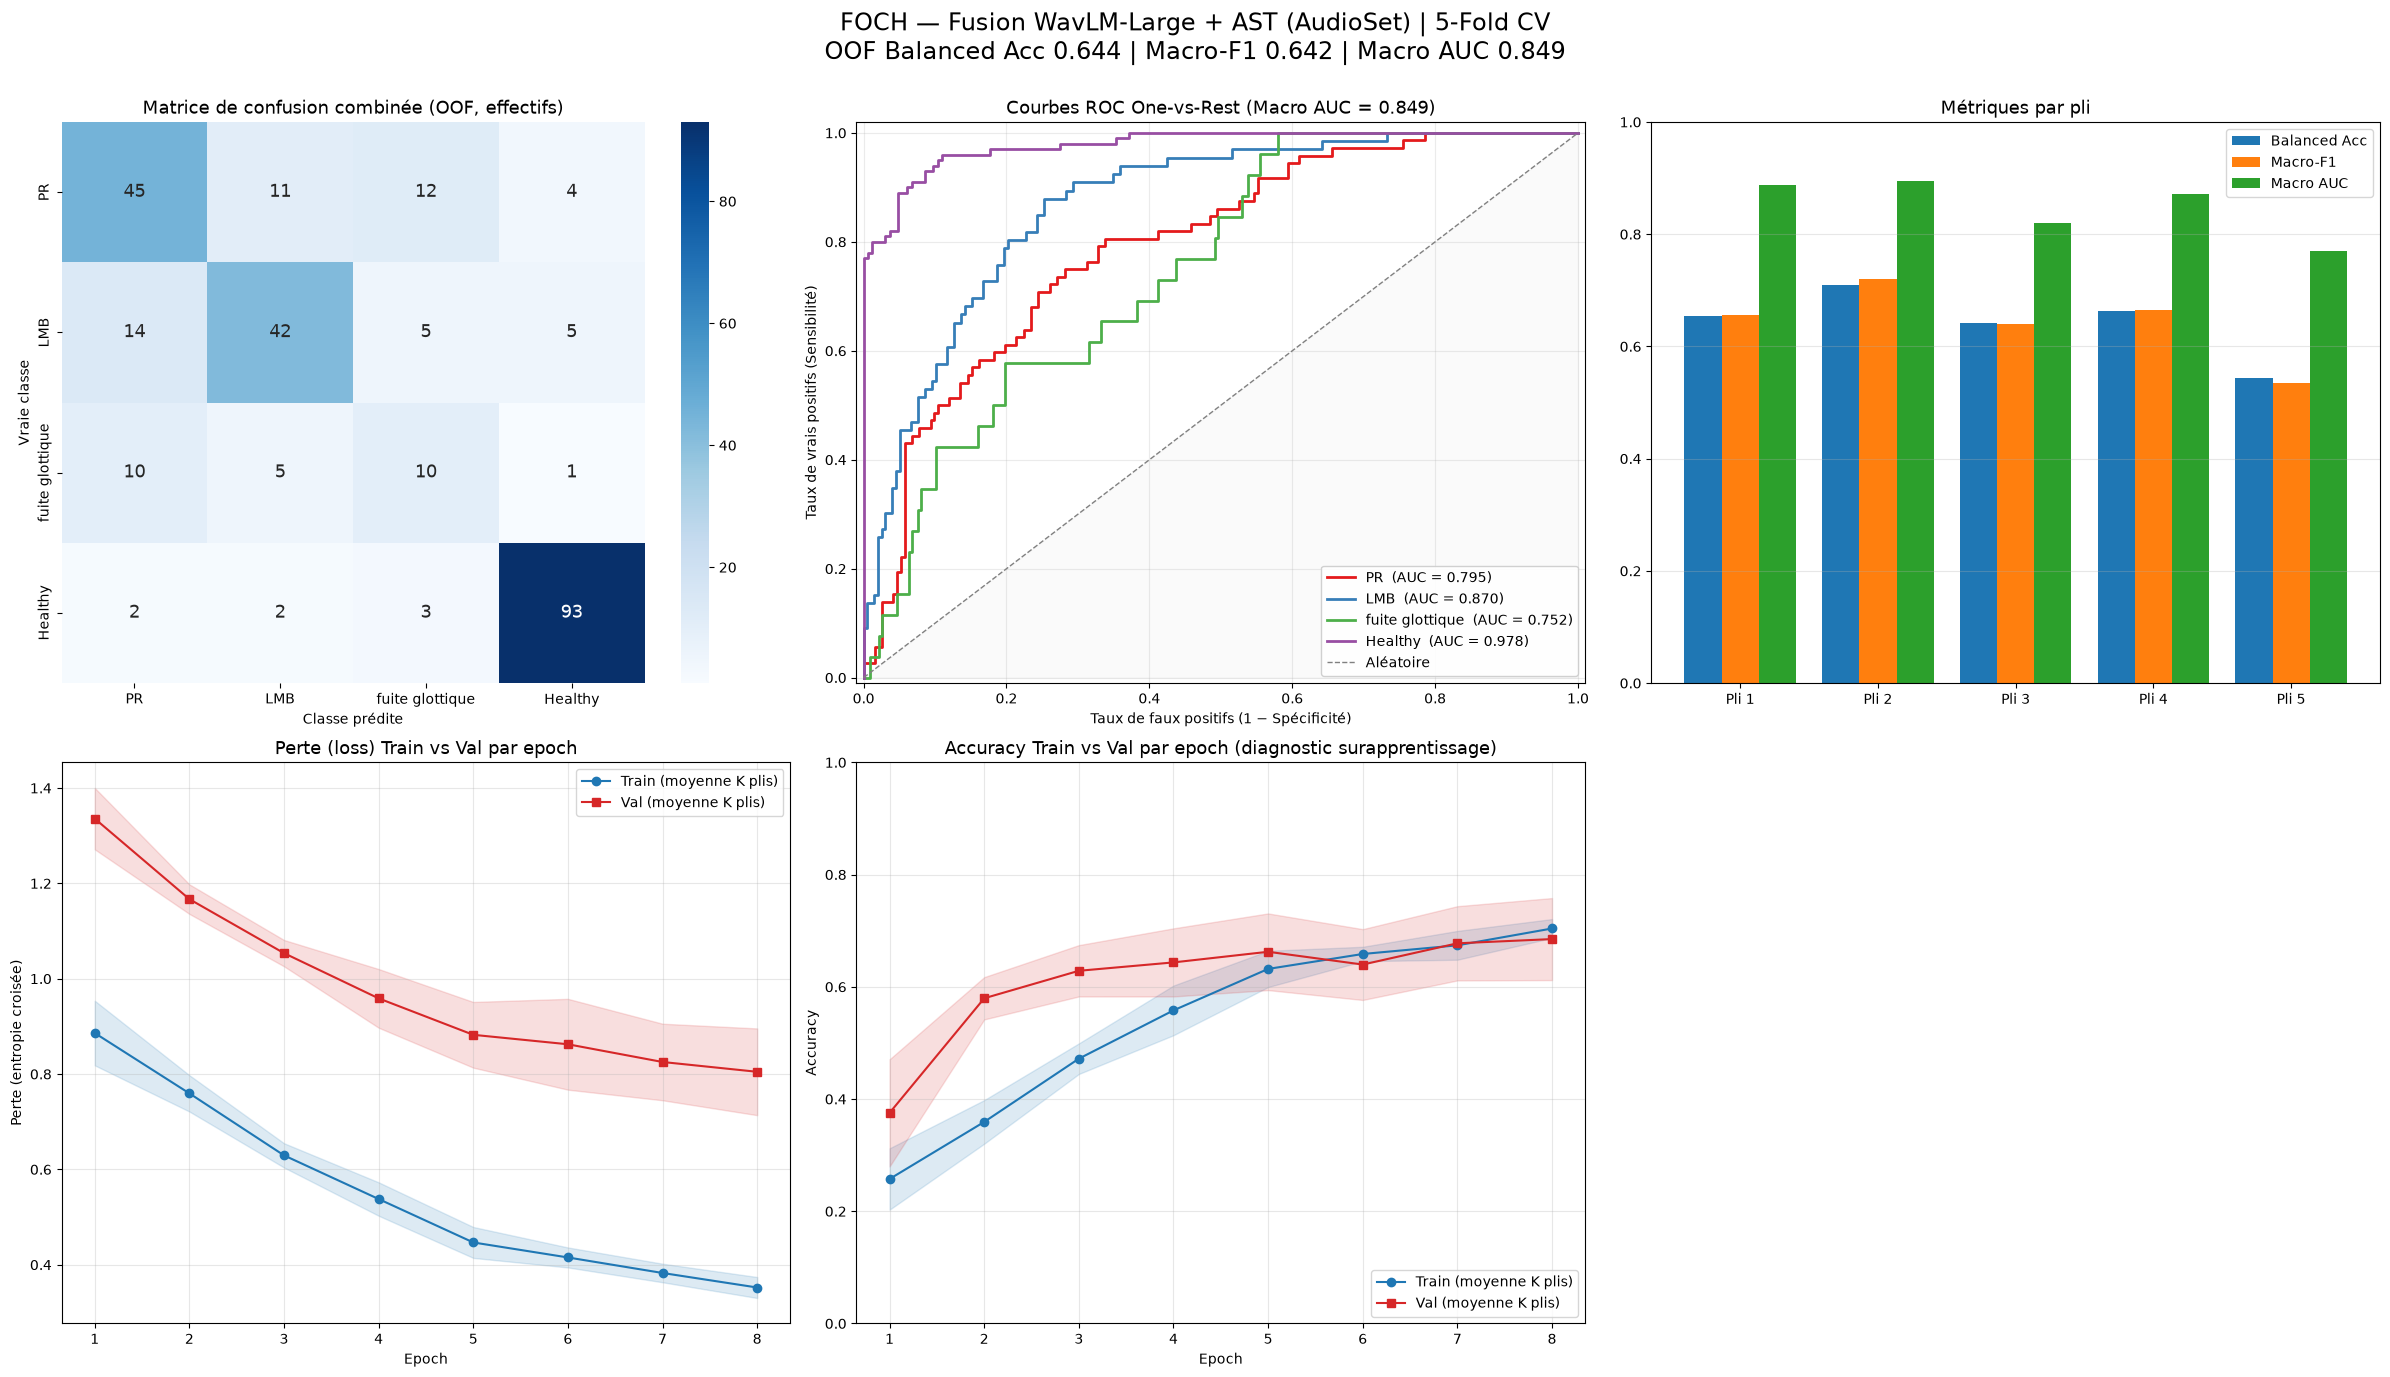


Artefacts sauvegardés dans C:/Users/AdminIA/Documents/models/.foch_métriques :
  • ast_large_kfold_aug_dashboard.png
  • ast_large_kfold_aug_metrics.json
  • ast_large_kfold_aug_confusion.csv
  • ast_large_kfold_aug_fold_metrics.csv


In [9]:
# ═══════════════════════════════════════════════════════════════════════════
# Cellule 8 — Évaluation agrégée out-of-fold (K-Fold) + tableau de bord
# ═══════════════════════════════════════════════════════════════════════════
import json
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_curve, auc as sk_auc)
from sklearn.preprocessing import label_binarize

assert (oof_labels >= 0).all(), "Des enregistrements n'ont pas été évalués !"

# ── Métriques agrégées ────────────────────────────────────────────────────────
print('Rapport de classification agrégé (out-of-fold) :')
print('\n' + classification_report(oof_labels, oof_preds, labels=labels_idx,
                                    target_names=CLASSES, digits=3, zero_division=0))
oof_bal = balanced_accuracy_score(oof_labels, oof_preds)
oof_mf1 = f1_score(oof_labels, oof_preds, average='macro', zero_division=0)
try:
    oof_auc = roc_auc_score(oof_labels, oof_probs, multi_class='ovr',
                            average='macro', labels=labels_idx)
except ValueError:
    oof_auc = float('nan')

mean_bal, std_bal = fold_df['balanced_accuracy'].mean(), fold_df['balanced_accuracy'].std()
mean_f1,  std_f1  = fold_df['macro_f1'].mean(),          fold_df['macro_f1'].std()
mean_auc, std_auc = fold_df['macro_auc_ovr'].mean(),     fold_df['macro_auc_ovr'].std()
print(f'OOF global        — Balanced Acc {oof_bal:.4f} | Macro-F1 {oof_mf1:.4f} | Macro AUC {oof_auc:.4f}')
print(f'Moyenne par pli   — Balanced Acc {mean_bal:.4f}±{std_bal:.4f} | '
      f'Macro-F1 {mean_f1:.4f}±{std_f1:.4f} | Macro AUC {mean_auc:.4f}±{std_auc:.4f}')

# ── Titre dynamique : reflète le preset BACKBONE réellement actif ─────────────
_arch_names = []
if WAVLM_VARIANT:               _arch_names.append(f'WavLM-{WAVLM_VARIANT.capitalize()}')
if AUDIO_BACKBONE == 'ast':     _arch_names.append('AST (AudioSet)')
elif AUDIO_BACKBONE == 'cnn14': _arch_names.append('CNN14 (SpeechBrain)')
_arch_txt = ' + '.join(_arch_names) if _arch_names else BACKBONE

# ── ROC par classe (One-vs-Rest) ──────────────────────────────────────────────
oof_labels_bin = label_binarize(oof_labels, classes=labels_idx)   # (n, 4)

# ── Tableau de bord 2×3 (agrandi) ─────────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(24, 14))
fig.suptitle(f'FOCH — Fusion {_arch_txt} | {K_FOLDS}-Fold CV\n'
             f'OOF Balanced Acc {oof_bal:.3f} | Macro-F1 {oof_mf1:.3f} | Macro AUC {oof_auc:.3f}',
             fontsize=17)

# ── [0, 0] Matrice de confusion (effectifs bruts) ─────────────────────────────
cm = confusion_matrix(oof_labels, oof_preds, labels=labels_idx)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0, 0],
            xticklabels=CLASSES, yticklabels=CLASSES, annot_kws={'size': 13})
axes[0, 0].set_title('Matrice de confusion combinée (OOF, effectifs)', fontsize=13)
axes[0, 0].set_ylabel('Vraie classe')
axes[0, 0].set_xlabel('Classe prédite')

# ── [0, 1] Courbes ROC OvR par classe ────────────────────────────────────────
_colors = ['#e41a1c', '#377eb8', '#4daf4a', '#984ea3']   # rouge, bleu, vert, violet
for i, (cls, col) in enumerate(zip(CLASSES, _colors)):
    fpr, tpr, _ = roc_curve(oof_labels_bin[:, i], oof_probs[:, i])
    auc_i = sk_auc(fpr, tpr)
    axes[0, 1].plot(fpr, tpr, color=col, lw=2, label=f'{cls}  (AUC = {auc_i:.3f})')

axes[0, 1].plot([0, 1], [0, 1], color='grey', lw=1, linestyle='--', label='Aléatoire')
axes[0, 1].fill_between([0, 1], [0, 1], alpha=0.04, color='grey')
axes[0, 1].set_xlim([-0.01, 1.01]); axes[0, 1].set_ylim([-0.01, 1.02])
axes[0, 1].set_xlabel('Taux de faux positifs (1 − Spécificité)')
axes[0, 1].set_ylabel('Taux de vrais positifs (Sensibilité)')
axes[0, 1].set_title(f'Courbes ROC One-vs-Rest (Macro AUC = {oof_auc:.3f})', fontsize=13)
axes[0, 1].legend(loc='lower right', framealpha=0.9)
axes[0, 1].grid(True, alpha=0.25)

# ── [0, 2] Métriques par pli ──────────────────────────────────────────────────
x = np.arange(K_FOLDS); w = 0.27
axes[0, 2].bar(x - w, fold_df['balanced_accuracy'], w, label='Balanced Acc')
axes[0, 2].bar(x,     fold_df['macro_f1'],          w, label='Macro-F1')
axes[0, 2].bar(x + w, fold_df['macro_auc_ovr'],     w, label='Macro AUC')
axes[0, 2].set_title('Métriques par pli', fontsize=13)
axes[0, 2].set_xticks(x)
axes[0, 2].set_xticklabels([f'Pli {i+1}' for i in range(K_FOLDS)])
axes[0, 2].set_ylim(0, 1)
axes[0, 2].legend()
axes[0, 2].grid(True, axis='y', alpha=0.3)

# ── [1, 0] Perte (loss) Train vs Val par epoch ────────────────────────────────
# Nécessite fold_train_loss / fold_curves (historisés Cellule 7).
assert 'fold_train_loss' in globals() and len(fold_train_loss), \
    "fold_train_loss manquant — réexécutez la Cellule 7 (boucle K-Fold) pour régénérer l'historique."
min_ep_loss = min(min(len(h) for h in fold_train_loss),
                   min(len(h) for h in fold_curves))
tr_loss = np.array([h[:min_ep_loss] for h in fold_train_loss])   # (K, min_ep)
va_loss = np.array([h[:min_ep_loss] for h in fold_curves])
ep_loss = np.arange(1, min_ep_loss + 1)
axes[1, 0].plot(ep_loss, tr_loss.mean(0), 'o-', color='#1f77b4', label='Train (moyenne K plis)')
axes[1, 0].fill_between(ep_loss, tr_loss.mean(0) - tr_loss.std(0), tr_loss.mean(0) + tr_loss.std(0),
                        color='#1f77b4', alpha=0.15)
axes[1, 0].plot(ep_loss, va_loss.mean(0), 's-', color='#d62728', label='Val (moyenne K plis)')
axes[1, 0].fill_between(ep_loss, va_loss.mean(0) - va_loss.std(0), va_loss.mean(0) + va_loss.std(0),
                        color='#d62728', alpha=0.15)
if UNFREEZE_ENABLED and UNFREEZE_AT_EPOCH < min_ep_loss:
    axes[1, 0].axvline(UNFREEZE_AT_EPOCH + 1, color='grey', ls='--', lw=1,
                       label=f'Dégel WavLM (epoch {UNFREEZE_AT_EPOCH + 1})')
axes[1, 0].set_title('Perte (loss) Train vs Val par epoch', fontsize=13)
axes[1, 0].set_xlabel('Epoch')
axes[1, 0].set_ylabel('Perte (entropie croisée)')
axes[1, 0].legend(loc='upper right')
axes[1, 0].grid(True, alpha=0.3)

# ── [1, 1] Diagnostic de surapprentissage : Train vs Val accuracy / epoch ─────
# Nécessite fold_train_acc / fold_val_acc (historisés Cellule 7).
assert 'fold_train_acc' in globals() and 'fold_val_acc' in globals() \
        and len(fold_train_acc) and len(fold_val_acc), \
    "fold_train_acc/fold_val_acc manquant — réexécutez la Cellule 7 (boucle K-Fold) pour régénérer l'historique."
min_ep = min(min(len(h) for h in fold_train_acc),
             min(len(h) for h in fold_val_acc))
tr = np.array([h[:min_ep] for h in fold_train_acc])   # (K, min_ep)
va = np.array([h[:min_ep] for h in fold_val_acc])
ep = np.arange(1, min_ep + 1)
axes[1, 1].plot(ep, tr.mean(0), 'o-', color='#1f77b4', label='Train (moyenne K plis)')
axes[1, 1].fill_between(ep, tr.mean(0) - tr.std(0), tr.mean(0) + tr.std(0),
                        color='#1f77b4', alpha=0.15)
axes[1, 1].plot(ep, va.mean(0), 's-', color='#d62728', label='Val (moyenne K plis)')
axes[1, 1].fill_between(ep, va.mean(0) - va.std(0), va.mean(0) + va.std(0),
                        color='#d62728', alpha=0.15)
if UNFREEZE_ENABLED and UNFREEZE_AT_EPOCH < min_ep:
    axes[1, 1].axvline(UNFREEZE_AT_EPOCH + 1, color='grey', ls='--', lw=1,
                       label=f'Dégel WavLM (epoch {UNFREEZE_AT_EPOCH + 1})')
axes[1, 1].set_title('Accuracy Train vs Val par epoch (diagnostic surapprentissage)',
                     fontsize=13)
axes[1, 1].set_xlabel('Epoch')
axes[1, 1].set_ylabel('Accuracy')
axes[1, 1].set_ylim(0, 1)
axes[1, 1].legend(loc='lower right')
axes[1, 1].grid(True, alpha=0.3)

# ── [1, 2] (grille 2×3 pour accueillir CM/ROC/Métriques + Loss/Accuracy) ──────
axes[1, 2].axis('off')

plt.tight_layout()
plt.subplots_adjust(top=0.90)
fig_path = os.path.join(METRICS_DIR, f'{RUN_NAME}_dashboard.png')
plt.savefig(fig_path, dpi=150, bbox_inches='tight')
plt.show()

# ── Sauvegarde des artefacts ──────────────────────────────────────────────────
report_dict = classification_report(oof_labels, oof_preds, labels=labels_idx,
                                     target_names=CLASSES, output_dict=True, zero_division=0)
metrics = {
    'run_name':               RUN_NAME,
    'architecture':           _arch_txt,
    'cv':                     f'StratifiedKFold(n_splits={K_FOLDS})',
    'oof_balanced_accuracy':  oof_bal,
    'oof_macro_f1':           oof_mf1,
    'oof_macro_auc_ovr':      oof_auc,
    'mean_balanced_accuracy': mean_bal, 'std_balanced_accuracy': std_bal,
    'mean_macro_f1':          mean_f1,  'std_macro_f1':          std_f1,
    'mean_macro_auc_ovr':     mean_auc, 'std_macro_auc_ovr':     std_auc,
    'per_fold':               fold_rows,
    'per_class_oof':          report_dict,
    'classes':                CLASSES,
    'n_total':                int(len(df)),
}
with open(os.path.join(METRICS_DIR, f'{RUN_NAME}_metrics.json'), 'w', encoding='utf-8') as f:
    json.dump(metrics, f, ensure_ascii=False, indent=2, default=float)
np.savetxt(os.path.join(METRICS_DIR, f'{RUN_NAME}_confusion.csv'), cm, fmt='%d', delimiter=',')
fold_df.to_csv(os.path.join(METRICS_DIR, f'{RUN_NAME}_fold_metrics.csv'), index=False)

print(f'\nArtefacts sauvegardés dans {METRICS_DIR} :')
print(f'  • {RUN_NAME}_dashboard.png')
print(f'  • {RUN_NAME}_metrics.json')
print(f'  • {RUN_NAME}_confusion.csv')
print(f'  • {RUN_NAME}_fold_metrics.csv')

In [10]:
print(type(fold_curves[0]))
print(fold_curves[0] if isinstance(fold_curves[0], dict) else fold_curves[0][:5])

<class 'list'>
[1.3775766066142492, 1.1438687869480677, 1.024018713406154, 0.8791120435510363, 0.8341466401304517]


## 9. Synthèse et prochaines étapes

Ce notebook met en œuvre un **classifieur multi-branche entièrement configurable** (préréglages `BACKBONE`, Cellule 1) évalué par **validation croisée stratifiée à 5 plis**, avec **augmentation de données** injectée pli par pli. Le backbone n'est pas figé en dur : `cnn14`, `ast`, leurs variantes solo, et `wavlm_base`/`wavlm_large` partagent la même boucle d'entraînement (Cellule 7) et le même `Dataset` bi-entrée (Cellule 4) — seule la dimension de fusion s'adapte automatiquement selon les branches sélectionnées (`MultiBranchFusion`, Cellule 6).

**Configuration actuellement active : `BACKBONE = 'ast_large'`** → fusion **AST (AudioSet, 768-d, gelé)** ⊕ **WavLM-Large (1024-d, gelé)** → 1792-d.

**Choix méthodologiques clés :**
- **Architecture modulaire** : une branche « audio-domaine » spectrale au choix (CNN14 *ou* AST, toutes deux pré-entraînées sur AudioSet) + une branche WavLM optionnelle (Base/Large) — cf. `_BACKBONE_PRESETS`, Cellule 1.
- **AST (config active)** : Vision Transformer pré-entraîné sur AudioSet en spectrogramme fbank 1024×128, utilisé ici en extracteur d'embeddings gelé (`pooler_output` 768-d) — capture des motifs spectro-temporels globaux sans réentraînement sur les ~300 échantillons FOCH.
- **WavLM-Large gelé** : détail acoustique fin (jitter, shimmer, apériodicité) en complément de la vue AST, plus macroscopique.
- **Tête de fusion régularisée** : les deux branches étant gelées, seule la tête MLP (`Dropout → Linear → LayerNorm → Dropout → ReLU → Linear`) est entraînable — cf. Cellule 6, avec dropout d'entrée et dropout interne renforcés pour limiter le surapprentissage observé sur ce head par ailleurs surparamétré au regard de la taille du jeu.
- **Validation croisée K-Fold** : métriques OOF + moyenne ± écart-type par pli.
- **Augmentation sans fuite** : segments injectés uniquement dans le train, patients de validation exclus.

**Pistes probables d'amélioration ultérieures :**
1. Comparer les presets (`ast_large`, `ast` +WavLM-Base, `cnn14`, `wavlm_large` seul, etc.) — la sonde VRAM (Cellule 6b) et la boucle (Cellule 7) s'adaptent automatiquement à chacun.
2. **Dégel progressif** (*progressive unfreezing*) d'AST et/ou WavLM au-delà de l'epoch de stabilisation de la tête (`UNFREEZE_ENABLED`, Cellule 1).
3. **SpecAugment** sur l'entrée fbank d'AST.
4. **Ensembling** des K modèles de plis à l'inférence.
5. **Audit qualité** des doublons d'homonymes (`MARTIN`) via `patient_id`.
6. Réduire encore `fusion_dim` (projection/PCA avant la tête) si le head reste sujet au surapprentissage malgré le dropout renforcé.

> ⚠️ **Rappel d'exécution** — cellules à exécuter **dans l'ordre** (1 → 8). Selon le preset `BACKBONE` choisi en Cellule 1, la Cellule 6 charge AST depuis `AST_DIR` (local) et/ou WavLM depuis `WAVLM_DIRS`, et ne télécharge le checkpoint CNN14 (`speechbrain/cnn14-esc50`) que si ce backbone est sélectionné. La Cellule 7 entraîne **K = 5 modèles** : prévoir un GPU CUDA et un temps d'exécution conséquent.

## 9. Synthèse et prochaines étapes

Ce notebook met en œuvre un **classifieur multi-branche entièrement configurable** (préréglages `BACKBONE`, Cellule 1) évalué par **validation croisée stratifiée à 5 plis**, avec **augmentation de données** injectée pli par pli. Le backbone n'est pas figé en dur : `cnn14`, `ast`, leurs variantes solo, et `wavlm_base`/`wavlm_large` partagent la même boucle d'entraînement (Cellule 7) et le même `Dataset` bi-entrée (Cellule 4) — seule la dimension de fusion s'adapte automatiquement selon les branches sélectionnées (`MultiBranchFusion`, Cellule 6).

**Configuration actuellement active : `BACKBONE = 'ast_large'`** → fusion **AST (AudioSet, 768-d, gelé)** ⊕ **WavLM-Large (1024-d, gelé)** → 1792-d.

**Choix méthodologiques clés :**
- **Architecture modulaire** : une branche « audio-domaine » spectrale au choix (CNN14 *ou* AST, toutes deux pré-entraînées sur AudioSet) + une branche WavLM optionnelle (Base/Large) — cf. `_BACKBONE_PRESETS`, Cellule 1.
- **AST (config active)** : Vision Transformer pré-entraîné sur AudioSet en spectrogramme fbank 1024×128, utilisé ici en extracteur d'embeddings gelé (`pooler_output` 768-d) — capture des motifs spectro-temporels globaux sans réentraînement sur les ~300 échantillons FOCH.
- **WavLM-Large gelé** : détail acoustique fin (jitter, shimmer, apériodicité) en complément de la vue AST, plus macroscopique.
- **Tête de fusion régularisée** : les deux branches étant gelées, seule la tête MLP (`Dropout → Linear → LayerNorm → Dropout → ReLU → Linear`) est entraînable — cf. Cellule 6, avec dropout d'entrée et dropout interne renforcés pour limiter le surapprentissage observé sur ce head par ailleurs surparamétré au regard de la taille du jeu.
- **Validation croisée K-Fold** : métriques OOF + moyenne ± écart-type par pli.
- **Augmentation sans fuite** : segments injectés uniquement dans le train, patients de validation exclus.

**Pistes probables d'amélioration ultérieures :**
1. Comparer les presets (`ast_large`, `ast` +WavLM-Base, `cnn14`, `wavlm_large` seul, etc.) — la sonde VRAM (Cellule 6b) et la boucle (Cellule 7) s'adaptent automatiquement à chacun.
2. **Dégel progressif** (*progressive unfreezing*) d'AST et/ou WavLM au-delà de l'epoch de stabilisation de la tête (`UNFREEZE_ENABLED`, Cellule 1).
3. **SpecAugment** sur l'entrée fbank d'AST.
4. **Ensembling** des K modèles de plis à l'inférence.
5. **Audit qualité** des doublons d'homonymes (`MARTIN`) via `patient_id`.
6. Réduire encore `fusion_dim` (projection/PCA avant la tête) si le head reste sujet au surapprentissage malgré le dropout renforcé.

> ⚠️ **Rappel d'exécution** — cellules à exécuter **dans l'ordre** (1 → 8). Selon le preset `BACKBONE` choisi en Cellule 1, la Cellule 6 charge AST depuis `AST_DIR` (local) et/ou WavLM depuis `WAVLM_DIRS`, et ne télécharge le checkpoint CNN14 (`speechbrain/cnn14-esc50`) que si ce backbone est sélectionné. La Cellule 7 entraîne **K = 5 modèles** : prévoir un GPU CUDA et un temps d'exécution conséquent.